In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from COMIND_transformer.visualization import *
from COMIND_transformer.utils import solve_system
from sklearn.decomposition import PCA
from scipy.stats import chi2_contingency, kendalltau
import os
import glob

# Find all grid search result files (run_ppmi_subtyping_gridsearch.py writes to <experiment>/results/)
result_dir = "/home/dsemchin/COMIND_experiments/2026_04_21_PPMI_kappa_lowmaxiter"
_results = os.path.join(result_dir, "results")
pattern = os.path.join(_results if os.path.isdir(_results) else result_dir, "PPMI_subtyping_grid_*.npz")
paths = sorted(glob.glob(pattern))
print(f"Found {len(paths)} result files")

def load_results(paths):
    results = {}
    for path in paths:
        key = os.path.splitext(os.path.basename(path))[0]
        try:
            data = np.load(path, allow_pickle=True)
            results[key] = data
        except Exception as e:
            print(f"Error loading {key}: {e}")
    return results

results = load_results(paths)
print(f"\nTotal loaded: {len(results)} results")

Found 144 result files

Total loaded: 144 results


In [19]:
# Load PPMI data for NHY (for Kendall tau with beta)
df = pd.read_csv("/data01/bgutman/MRI_data/PPMI/data_ppmi_pd.csv")
nhy_all = df["NHY"].to_numpy()
ids_all_nhy = df["subj_id"].to_numpy()
pid_to_nhy = {}
for pid in np.unique(ids_all_nhy):
    mask = ids_all_nhy == pid
    pid_to_nhy[pid] = np.mean(nhy_all[mask])

# Extract summary statistics for all models (including Kendall tau vs NHY)
n_biomarkers = 68
summary = []

for cand, data in results.items():
    try:
        final_lse = data["lse_history"][-1] if "lse_history" in data.files else np.nan

        if "cluster_f" in data.files:
            cluster_f = data["cluster_f"]
            n_subtypes = cluster_f.shape[0]
            f_sparsity = int(np.sum(cluster_f < 0.01))
        else:
            cluster_f = None
            n_subtypes = 0
            f_sparsity = np.nan

        final_scalar_K = data["final_scalar_K"] if "final_scalar_K" in data.files else np.nan
        final_s = data["final_s"] if "final_s" in data.files else np.nan
        candidate_num = data["candidate"] if "candidate" in data.files else int(cand.split("_")[-1])
        lambda_cog = data["lambda_cog"] if "lambda_cog" in data.files else np.nan
        lambda_jsd = data["lambda_jsd"] if "lambda_jsd" in data.files else np.nan
        lambda_f = data["lambda_f"] if "lambda_f" in data.files else np.nan
        lambda_scalar = data["lambda_scalar"] if "lambda_scalar" in data.files else np.nan

        if "final_assignments" in data.files:
            assignments = data["final_assignments"]
            subtype_counts = np.bincount(assignments, minlength=n_subtypes) if n_subtypes > 0 else []
        else:
            subtype_counts = []

        bic = float(data["bic"]) if "bic" in data.files else np.nan
        cv_mean_lse = float(data["cv_mean_lse"]) if "cv_mean_lse" in data.files else np.nan

        # Kendall tau (beta vs NHY) for this candidate
        kendall_tau = np.nan
        p_value = np.nan
        if "train_ids" in data.files and "beta_history" in data.files:
            train_ids = data["train_ids"]
            beta_train = data["beta_history"][:, -1]
            beta_vals = []
            nhy_vals = []
            for pid, beta in zip(train_ids, beta_train):
                if pid in pid_to_nhy:
                    beta_vals.append(beta)
                    nhy_vals.append(pid_to_nhy[pid])
            if len(beta_vals) >= 2:
                kendall_tau, p_value = kendalltau(beta_vals, nhy_vals)

        summary.append({
            "candidate": candidate_num,
            "key": cand,
            "final_lse": final_lse,
            "cv_mean_lse": cv_mean_lse,
            "bic": bic,
            "n_subtypes": n_subtypes,
            "scalar_K": final_scalar_K,
            "mean_s": np.mean(final_s) if isinstance(final_s, np.ndarray) else final_s,
            "lambda_cog": lambda_cog,
            "lambda_jsd": lambda_jsd,
            "lambda_f": lambda_f,
            "lambda_scalar": lambda_scalar,
            "f_sparsity": f_sparsity,
            "subtype0_count": subtype_counts[0] if len(subtype_counts) > 0 else np.nan,
            "subtype1_count": subtype_counts[1] if len(subtype_counts) > 1 else np.nan,
            "kendall_tau": kendall_tau,
            "p_value": p_value,
        })
    except Exception as e:
        print(f"Error processing {cand}: {e}")
        continue

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values("cv_mean_lse").reset_index(drop=True)

print("\nSummary Statistics (sorted by CV LSE)")
print(summary_df[["candidate", "final_lse", "cv_mean_lse", "bic", "n_subtypes", "kendall_tau", "p_value",
                  "scalar_K", "mean_s", "lambda_cog", "lambda_jsd", "lambda_f", "lambda_scalar", "f_sparsity"]].head(10))


Summary Statistics (sorted by CV LSE)
  candidate   final_lse  cv_mean_lse           bic  n_subtypes  kendall_tau  \
0        56  571.373783   194.508620  53976.199908           3     0.263572   
1         9  573.207506   195.531173  54143.932867           3     0.225050   
2        58  570.385887   195.795111  53979.249917           3     0.206896   
3       106  572.994434   196.632780  54041.969596           3     0.208154   
4        61  556.356698   196.649746  52863.441145           3     0.150551   
5        55  587.844240   197.438961  54547.541578           3     0.233346   
6        53  586.466039   197.510543  54529.165182           3     0.253623   
7         7  582.990532   197.561921  54417.776471           3     0.238746   
8         0  599.129062   197.574902  54928.561148           3     0.228429   
9        59  574.541990   197.618476  54072.256640           3     0.182683   

    p_value            scalar_K    mean_s lambda_cog lambda_jsd lambda_f  \
0  0.000097   2

In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# --- Rebuild the same PPMI training set as in run_ppmi_subtyping_gridsearch.py ---

# Load PPMI (same path as run script)
df = pd.read_csv("/home/dsemchin/data/data_ppmi_pd.csv")

# Connectivity K is not needed here for BIC recomputation

# Remove non-longitudinal observations, drop NA, same filters
relevant_cols = [col for col in df.columns
                 if col.startswith(('L_', 'R_'))
                 and ('_thickavg' in col or '_thickavg_resid' in col)]
relevant_cols += ["MCATOT", "TD_score", "PIGD_score"]

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=relevant_cols)

subj_counts = df['subj_id'].value_counts()
longitudinal_ids = subj_counts[subj_counts > 1].index
df = df[df['subj_id'].isin(longitudinal_ids)].copy()
df = df.drop_duplicates(subset=["subj_id", "time"])

# Biomarkers (same definition as run script)
X_obs_all = df[[col for col in df.columns
                if col.startswith(('L_', 'R_'))
                and col.endswith('_thickavg')
                and not col.endswith('_thickavg_resid')]].to_numpy()

# Flip so baseline ~ 0: same as run script
X_obs_all = np.max(X_obs_all, axis=0) - X_obs_all

ids_all = df["subj_id"].to_numpy()
dt_all = df["time"].to_numpy() / 12.0  # years
cog_all = df[["MCATOT", "TD_score", "PIGD_score"]].to_numpy()

# NSD / NHY processing not needed for BIC

# Recreate initial_beta (same function, same RNG/params)
from COMIND_transformer.utils import fit_mixedlm_beta_from_clinical

initial_beta_all, pid_to_beta, _ = fit_mixedlm_beta_from_clinical(
    df=df,
    ids=ids_all,
    dt=dt_all,
    t_max=40,
    verbose=True,
    rng=np.random.default_rng(75),
)

# Build patient list as in run script
def create_patient_list(X_obs, ids, dt, cog, initial_beta=None):
    unique_ids = np.unique(ids)
    id_to_index = {pid: idx for idx, pid in enumerate(unique_ids)}

    patient_list = []
    for pid in unique_ids:
        mask = (ids == pid)
        patient_data = {
            "id": pid,
            "X_obs": X_obs[mask],
            "dt": dt[mask],
            "cog": cog[mask],
        }
        if initial_beta is not None:
            patient_data["initial_beta"] = initial_beta[id_to_index[pid]]
        patient_list.append(patient_data)

    return patient_list

X_full = create_patient_list(X_obs_all, ids_all, dt_all, cog_all, initial_beta_all)

# Use the same train/val split as run script
X_train, X_val = train_test_split(X_full, test_size=0.2, random_state=75)

# Stack training observations to get X_obs_train
X_obs_train = np.vstack([p["X_obs"] for p in X_train])
n_biomarkers = X_obs_train.shape[1]

# Null/reference variance per biomarker (overall variance on training data)
var_null = np.var(X_obs_train, axis=0, ddof=1)
var_null = np.maximum(var_null, 1e-12)

beta_init summary: count    146.000000
mean      15.622559
std        7.789749
min        0.000000
25%        9.586119
50%       15.547791
75%       20.682329
max       40.000000
dtype: float64


In [21]:
import numpy as np
import pandas as pd

def bic_n_params_from_saved(cluster_f, lambda_cog, cluster_cog_a, f_threshold=0.05):
    """
    Mirror current _bic_n_params:
    K = n_biomarkers (s) + 1 (time scale)
        + (n_cog * n_subtypes + n_subtypes) if lambda_cog > 0
        + sum over subtypes of #(f_i >= f_threshold)
    """
    n_subtypes, n_biomarkers = cluster_f.shape
    k = n_biomarkers + 1

    if (lambda_cog is not None) and float(lambda_cog) > 0 and cluster_cog_a is not None and len(cluster_cog_a) > 0:
        first_cog_a = np.asarray(cluster_cog_a[0])
        n_cog = first_cog_a.shape[0]
        k += n_cog * n_subtypes
        k += n_subtypes  # cog_b per subtype

    for subtype in range(n_subtypes):
        f_sub = np.ravel(cluster_f[subtype])
        k += int(np.sum(f_sub >= f_threshold))

    return k

# Recompute BIC using new formula for each result
bic_new_list = []
keys_order = list(results.keys())

for key in keys_order:
    data = results[key]
    try:
        cluster_f = data["cluster_f"]
        sse_per_b = data["sse_per_biomarker"]
        n_obs = int(data["n_obs"])  # total scalar observations

        lambda_cog = float(data["lambda_cog"]) if "lambda_cog" in data.files else 0.0
        cluster_cog_a = data["cluster_cog_a"] if "cluster_cog_a" in data.files else None

        # Parameter count with current threshold (>= 0.05)
        k_params = bic_n_params_from_saved(cluster_f, lambda_cog, cluster_cog_a, f_threshold=0.05)

        # SSE_norm with null/reference variance
        if sse_per_b.shape[0] != var_null.shape[0]:
            raise ValueError(f"Shape mismatch: sse_per_b {sse_per_b.shape}, var_null {var_null.shape}")
        sse_norm = float(np.sum(sse_per_b / var_null))

        bic_new = k_params * np.log(n_obs) + 2.0 * sse_norm
    except Exception as e:
        print(f"Error recomputing BIC for {key}: {e}")
        bic_new = np.nan

    bic_new_list.append(bic_new)

# Map back to summary_df (assuming summary_df['key'] holds the npz keys)
bic_new_series = pd.Series(bic_new_list, index=keys_order)
summary_df["bic_new"] = summary_df["key"].map(bic_new_series)

print("\nSummary Statistics with new BIC (bic_new):")
cols = ["candidate", "final_lse", "cv_mean_lse", "bic", "bic_new",
        "n_subtypes", "kendall_tau", "p_value",
        "scalar_K", "mean_s", "lambda_cog", "lambda_jsd", "lambda_f", "lambda_scalar", "f_sparsity"]
print(summary_df[[c for c in cols if c in summary_df.columns]].head(10))


Summary Statistics with new BIC (bic_new):
  candidate   final_lse  cv_mean_lse           bic       bic_new  n_subtypes  \
0        56  571.373783   194.508620  53976.199908  53874.065217           3   
1         9  573.207506   195.531173  54143.932867  54041.798175           3   
2        58  570.385887   195.795111  53979.249917  53856.688287           3   
3       106  572.994434   196.632780  54041.969596  53970.475312           3   
4        61  556.356698   196.649746  52863.441145  52495.756256           3   
5        55  587.844240   197.438961  54547.541578  54516.901170           3   
6        53  586.466039   197.510543  54529.165182  54478.097836           3   
7         7  582.990532   197.561921  54417.776471  54346.282187           3   
8         0  599.129062   197.574902  54928.561148  54908.134210           3   
9        59  574.541990   197.618476  54072.256640  54021.189294           3   

   kendall_tau   p_value            scalar_K    mean_s lambda_cog lambda_js

### MODEL SELECTION

In [22]:
inspect_candidate = None
#inspect_candidate = 186

if inspect_candidate is None:
    # 2-stage selection
    # Stage 1: For each K (n_subtypes), pick hyperparameters with lowest CV LSE
    # Stage 2: Among those best-per-K models, pick the one with best (lowest) BIC
    df_bic = summary_df[summary_df["bic"].notna()].copy()
    if len(df_bic) == 0:
        best_row = summary_df.sort_values("cv_mean_lse").iloc[0]
        best_key = best_row["key"]
        best_data = results[best_key]
        print("\nBEST MODEL (by CV LSE, no BIC in results)")
    else:
        best_per_K = df_bic.loc[df_bic.groupby("n_subtypes")["cv_mean_lse"].idxmin()]
        idx_best = best_per_K["bic"].idxmin()
        best_row = best_per_K.loc[idx_best]
        best_key = best_row["key"]
        best_data = results[best_key]
        print("\nBEST MODEL (2-stage: best CV LSE per K, then best BIC among those)")
        print("Stage 1 - Best per K (by CV LSE):")
        for _, r in best_per_K.sort_values("n_subtypes").iterrows():
            print(f"  K={int(r['n_subtypes'])}: candidate={r['candidate']}, cv_mean_lse={r['cv_mean_lse']:.6f}, bic={r['bic']:.4f}")
        print(f"\nStage 2 - Selected K={int(best_row['n_subtypes'])} (lowest BIC among above).")
else:
    # Inspect specific candidate
    match = summary_df[summary_df["candidate"] == inspect_candidate]
    if len(match) == 0:
        raise ValueError(f"No result found for candidate {inspect_candidate}")
    best_row = match.iloc[0]
    best_key = best_row["key"]
    best_data = results[best_key]
    print(f"\nINSPECTING CANDIDATE {inspect_candidate} (best_* set to this run)")

print(f"Key: {best_key}")
print(f"n_subtypes: {best_row['n_subtypes']}, Final LSE: {best_row['final_lse']:.6f}")
if "bic" in best_row and pd.notna(best_row["bic"]):
    print(f"BIC: {best_row['bic']:.4f}, CV mean LSE: {best_row['cv_mean_lse']:.6f}")
if "lambda_f" in best_data.files:
    print(f"\nParameters:")
    print(f"  lambda_f: {best_data['lambda_f']}")
    print(f"  lambda_cog: {best_data['lambda_cog']}")
    print(f"  lambda_scalar: {best_data['lambda_scalar']}")
    print(f"  lambda_jsd: {best_data['lambda_jsd']}")
    print(f"  lambda_beta: {best_data['lambda_beta']}")


BEST MODEL (2-stage: best CV LSE per K, then best BIC among those)
Stage 1 - Best per K (by CV LSE):
  K=3: candidate=56, cv_mean_lse=194.508620, bic=53976.1999

Stage 2 - Selected K=3 (lowest BIC among above).
Key: PPMI_subtyping_grid_betajsd_056_lambda_f1p200_lambda_cog0p000_lambda_scalar5p000_lambda_jsd0_lambda_beta0p000_n_subtypes3_lambda_kappa1p200
n_subtypes: 3, Final LSE: 571.373783
BIC: 53976.1999, CV mean LSE: 194.508620

Parameters:
  lambda_f: 1.2
  lambda_cog: 0.0
  lambda_scalar: 5.0
  lambda_jsd: 0
  lambda_beta: 0.0


In [23]:
# Find best candidates for transform LSE (with and without cognitive priors)
transform_summary = []

for cand, data in results.items():
    try:
        candidate_num = data["candidate"] if "candidate" in data.files else int(cand.split("_")[-1])
        
        # Extract validation LSE values
        val_lse_with_cog = data["val_lse_with_cog"] if "val_lse_with_cog" in data.files else np.nan
        val_lse_no_cog = data["val_lse_no_cog"] if "val_lse_no_cog" in data.files else np.nan
        
        # Extract parameters
        lambda_f = data["lambda_f"] if "lambda_f" in data.files else np.nan
        lambda_cog = data["lambda_cog"] if "lambda_cog" in data.files else np.nan
        lambda_scalar = data["lambda_scalar"] if "lambda_scalar" in data.files else np.nan
        lambda_jsd = data["lambda_jsd"] if "lambda_jsd" in data.files else np.nan
        lambda_beta = data["lambda_beta"] if "lambda_beta" in data.files else np.nan
        
        transform_summary.append({
            "candidate": candidate_num,
            "key": cand,
            "val_lse_with_cog": val_lse_with_cog,
            "val_lse_no_cog": val_lse_no_cog,
            "lambda_f": lambda_f,
            "lambda_cog": lambda_cog,
            "lambda_scalar": lambda_scalar,
            "lambda_jsd": lambda_jsd,
            "lambda_beta": lambda_beta,
        })
    except Exception as e:
        print(f"Error processing {cand}: {e}")
        continue

transform_df = pd.DataFrame(transform_summary)

print(transform_df.shape)


(144, 9)


In [24]:
# Use the best model (lowest training LSE) for both with and without cognitive priors
print(f"Key: {best_key}")
print(f"Training LSE: {best_row['final_lse']:.6f}")

# Get validation LSE values from best_data if available
val_lse_with_cog = best_data["val_lse_with_cog"] if "val_lse_with_cog" in best_data.files else np.nan
val_lse_no_cog = best_data["val_lse_no_cog"] if "val_lse_no_cog" in best_data.files else np.nan

print(f"Validation LSE (with cog): {val_lse_with_cog:.6f}")
print(f"Validation LSE (no cog): {val_lse_no_cog:.6f}")

if "lambda_f" in best_data.files:
    print(f"\nParameters:")
    print(f"  lambda_f: {best_data['lambda_f']}")
    print(f"  lambda_cog: {best_data['lambda_cog']}")
    print(f"  lambda_scalar: {best_data['lambda_scalar']}")
    print(f"  lambda_jsd: {best_data['lambda_jsd']}")
    print(f"  lambda_beta: {best_data['lambda_beta']}")

# Get subtype assignments from best_data
train_assignments = best_data['train_assignments']
val_with = best_data['val_assignments_with_cog'] if 'val_assignments_with_cog' in best_data.files else []
val_no = best_data['val_assignments_no_cog'] if 'val_assignments_no_cog' in best_data.files else []
n_subtypes = len(np.unique(train_assignments))

print(f"\nTraining Set")
print(f"Subtype counts:")
for k in range(n_subtypes):
    print(f"  Subtype {k}: {np.sum(train_assignments == k)} patients")
print(f"  Total: {len(train_assignments)} patients")

print(f"\nValidation Set")
print(f"Subtype counts (with cog):")
for k in range(n_subtypes):
    print(f"  Subtype {k}: {np.sum(val_with == k)} patients")
print(f"  Total: {len(val_with)} patients")

print(f"\nSubtype counts (no cog):")
for k in range(n_subtypes):
    print(f"  Subtype {k}: {np.sum(val_no == k)} patients")
print(f"  Total: {len(val_no)} patients")

Key: PPMI_subtyping_grid_betajsd_056_lambda_f1p200_lambda_cog0p000_lambda_scalar5p000_lambda_jsd0_lambda_beta0p000_n_subtypes3_lambda_kappa1p200
Training LSE: 571.373783
Validation LSE (with cog): 153.509591
Validation LSE (no cog): 153.509591

Parameters:
  lambda_f: 1.2
  lambda_cog: 0.0
  lambda_scalar: 5.0
  lambda_jsd: 0
  lambda_beta: 0.0

Training Set
Subtype counts:
  Subtype 0: 52 patients
  Subtype 1: 24 patients
  Subtype 2: 40 patients
  Total: 116 patients

Validation Set
Subtype counts (with cog):
  Subtype 0: 8 patients
  Subtype 1: 14 patients
  Subtype 2: 8 patients
  Total: 30 patients

Subtype counts (no cog):
  Subtype 0: 8 patients
  Subtype 1: 14 patients
  Subtype 2: 8 patients
  Total: 30 patients


### hist of transform LSE differences

/tmp/ipykernel_11987/741470681.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


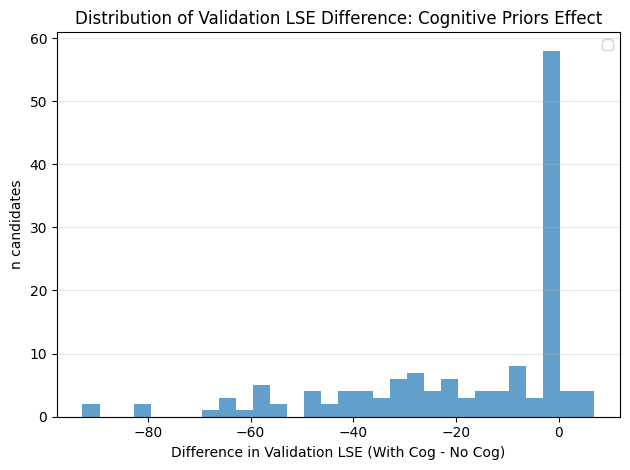

86 10


In [25]:
transform_df["lse_diff"] = transform_df["val_lse_with_cog"] - transform_df["val_lse_no_cog"]
valid_diff = transform_df.dropna(subset=["lse_diff"])

# Plot histogram
plt.hist(valid_diff['lse_diff'], bins=30, alpha=0.7)
plt.xlabel('Difference in Validation LSE (With Cog - No Cog)')
plt.ylabel('n candidates')
plt.title('Distribution of Validation LSE Difference: Cognitive Priors Effect')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

n_better_with_cog = (valid_diff['lse_diff'] < 0).sum()
n_worse_with_cog = (valid_diff['lse_diff'] > 0).sum()
print(n_better_with_cog, n_worse_with_cog)    

In [26]:
# Load PPMI data for analysis
df = pd.read_csv("/data01/bgutman/MRI_data/PPMI/data_ppmi_pd.csv")
df_K = pd.read_csv("/home/dsemchin/data/iit_connectivity_matrix/streamline_normalized_top_regions/iit_connectome_top_20.csv")
## remove non-longitudinal observations
print("original size:", df.shape)
relevant_cols = [col for col in df.columns if col.startswith(('L_', 'R_')) and ('_thickavg' in col or '_thickavg_resid' in col)]
relevant_cols += ["MCATOT", "TD_score", "PIGD_score"]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=relevant_cols)

subj_counts = df['subj_id'].value_counts()
longitudinal_ids = subj_counts[subj_counts > 1].index
df = df[df['subj_id'].isin(longitudinal_ids)].copy()
df = df.drop_duplicates(subset=["subj_id", "time"])

X_obs = df[[col for col in df.columns if (col.startswith(('L_', 'R_')) and col.endswith('_thickavg') and not col.endswith('_thickavg_resid'))]]
X_obs = X_obs.to_numpy()
X_obs = np.max(X_obs, axis=0) - X_obs

## connectivity matrix to numpy
K = df_K.drop(df_K.columns[0], axis=1).to_numpy()
np.fill_diagonal(K, 0)

# normalization
row_sums = K.sum(axis=1)
median_row_sum = np.median(row_sums)
K = K / median_row_sum

t_max = 40
t_span = np.linspace(0, t_max, int(t_max/0.01))

biomarker_names = [col for col in df.columns 
                   if col.startswith(('L_', 'R_')) and 
                   col.endswith('_thickavg') and 
                   not col.endswith('_thickavg_resid')]

# Extract arrays for analysis
ids_all = df["subj_id"].to_numpy()
dt_all = df["time"].to_numpy()/12  # convert to years
nhy_all = df["NHY"].to_numpy()
cog_all = df[["MCATOT","TD_score","PIGD_score"]].to_numpy()
df["NSD_STAGE"] = df["NSD_STAGE"].replace({"Not NSD": 0, "2b": 2})
df["NSD_STAGE"] = pd.to_numeric(df["NSD_STAGE"], errors='coerce')
nsd = df["NSD_STAGE"].to_numpy()

print(f"Loaded data: {X_obs.shape}, K: {K.shape}, biomarkers: {len(biomarker_names)}")
print(f"Patients: {len(np.unique(ids_all))}, Observations: {len(ids_all)}")


original size: (880, 250)
Loaded data: (504, 68), K: (68, 68), biomarkers: 68
Patients: 146, Observations: 504


In [27]:
# Extract best model assignments and betas
train_ids = best_data["train_ids"]
val_ids = best_data["val_ids"] if "val_ids" in best_data.files else []
beta_train = best_data["beta_history"][:, -1]
beta_val = best_data["beta_val"] if "beta_val" in best_data.files else []

print(f"Training patients: {len(train_ids)}")
print(f"Validation patients: {len(val_ids)}")

# Combine train and val
all_ids_list = list(train_ids) + list(val_ids)
all_betas_list = list(beta_train) + list(beta_val)
pid_to_beta = {pid: beta for pid, beta in zip(all_ids_list, all_betas_list)}

train_assignments = best_data["train_assignments"]
val_assignments = best_data["val_assignments"] if "val_assignments" in best_data.files else []
all_assignments_list = list(train_assignments) + list(val_assignments)
pid_to_assignment = {pid: assign for pid, assign in zip(all_ids_list, all_assignments_list)}

# Get beta values and assignments aligned with ids_all
beta_all = np.array([pid_to_beta.get(pid, np.nan) for pid in ids_all])
assignment_all = np.array([pid_to_assignment.get(pid, -1) for pid in ids_all])

# Filter to valid patients
valid_mask = np.array([pid in pid_to_beta for pid in ids_all])
ids_valid = ids_all[valid_mask]
beta_valid = beta_all[valid_mask]
assignment_valid = assignment_all[valid_mask]
nhy_valid = nhy_all[valid_mask]
nsd_valid = nsd[valid_mask]
cog_valid = cog_all[valid_mask]

# Count unique patients per subtype (not observations!)
unique_valid_pids = np.unique(ids_valid)
patient_assignments = np.array([pid_to_assignment.get(pid, -1) for pid in unique_valid_pids])

n_subtypes = len(np.unique(patient_assignments[patient_assignments >= 0]))
print(f"Total subject: {len(unique_valid_pids)}\n")
for k in range(n_subtypes):
    print(f"Subtype {k}: {np.sum(patient_assignments == k)} patients")

# Breakdown by train vs validation
train_patient_assignments = np.array([pid_to_assignment.get(pid, -1) for pid in train_ids])
val_patient_assignments = np.array([pid_to_assignment.get(pid, -1) for pid in val_ids])

print(f"\nTraining set:")
print(f"  Total: {len(train_ids)} patients")
for k in range(n_subtypes):
    print(f"  Subtype {k}: {np.sum(train_patient_assignments == k)} patients")

print(f"\nValidation set:")
print(f"  Total: {len(val_ids)} patients")
for k in range(n_subtypes):
    print(f"  Subtype {k}: {np.sum(val_patient_assignments == k)} patients")

Training patients: 116
Validation patients: 30
Total subject: 146

Subtype 0: 60 patients
Subtype 1: 38 patients
Subtype 2: 48 patients

Training set:
  Total: 116 patients
  Subtype 0: 52 patients
  Subtype 1: 24 patients
  Subtype 2: 40 patients

Validation set:
  Total: 30 patients
  Subtype 0: 8 patients
  Subtype 1: 14 patients
  Subtype 2: 8 patients


In [28]:
print(cluster_f[0])

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.02520805 0.         0.         0.02848752
 0.         0.00883384 0.         0.         0.         0.
 0.03516818 0.         0.         0.         0.         0.
 0.03495854 0.00264096 0.02586682 0.         0.         0.01867947
 0.         0.         0.02997463 0.         0.         0.
 0.         0.         0.         0.00734544 0.         0.
 0.00325573 0.         0.         0.01429944 0.00667727 0.
 0.         0.         0.         0.         0.02654953 0.
 0.         0.         0.         0.         0.02163332 0.02218729
 0.02730915 0.        ]



Subtype 0:
  Intercept (cog_b): 27.7628
  MCATOT coefficient: -0.7919
  TD_score coefficient: 0.7897
  PIGD_score coefficient: 2.2035
s_ij = 27.7628 +-0.7919 * MCATOT +0.7897 * TD +2.2035 * PIGD

Subtype 1:
  Intercept (cog_b): 54.8737
  MCATOT coefficient: -1.5844
  TD_score coefficient: 0.6299
  PIGD_score coefficient: 1.3036
s_ij = 54.8737 +-1.5844 * MCATOT +0.6299 * TD +1.3036 * PIGD

Subtype 2:
  Intercept (cog_b): 43.1113
  MCATOT coefficient: -1.1888
  TD_score coefficient: 0.7004
  PIGD_score coefficient: 1.6715
s_ij = 43.1113 +-1.1888 * MCATOT +0.7004 * TD +1.6715 * PIGD


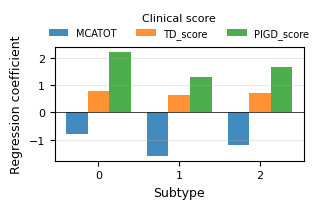

In [29]:
# Cognitive Parameter Comparison (general for any number of subtypes from best model)
cluster_cog_a = np.asarray(best_data["cluster_cog_a"])  # (n_subtypes, n_cog_features)
cluster_cog_b = np.atleast_1d(np.asarray(best_data["cluster_cog_b"]))  # (n_subtypes,)
n_subtypes = cluster_cog_b.shape[0]  # derive from data so it matches loaded arrays

cog_feature_names = ['MCATOT', 'TD_score', 'PIGD_score']

for subtype in range(n_subtypes):
    print(f"\nSubtype {subtype}:")
    print(f"  Intercept (cog_b): {cluster_cog_b[subtype]:.4f}")
    for i, name in enumerate(cog_feature_names):
        print(f"  {name} coefficient: {cluster_cog_a[subtype, i]:.4f}")

    print(f"s_ij = {cluster_cog_b[subtype]:.4f} +\
{cluster_cog_a[subtype, 0]:.4f} * MCATOT +\
{cluster_cog_a[subtype, 1]:.4f} * TD +\
{cluster_cog_a[subtype, 2]:.4f} * PIGD")


fig, ax = plt.subplots(figsize=(3.3, 2.5))  # single-column friendly

x = np.arange(n_subtypes)
width = 0.8 / len(cog_feature_names)

for feat_idx, feat_name in enumerate(cog_feature_names):
    offset = (feat_idx - (len(cog_feature_names) - 1) / 2) * width
    values = cluster_cog_a[:, feat_idx]
    ax.bar(
        x + offset,
        values,
        width,
        label=feat_name,
        alpha=0.85,
    )

ax.set_xlabel("Subtype", fontsize=9)
ax.set_ylabel("Regression coefficient", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([f"{s}" for s in range(n_subtypes)], fontsize=8)
ax.tick_params(axis="y", labelsize=8)

# Light horizontal grid for readability
ax.grid(True, alpha=0.3, axis="y")
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)

# Compact legend above/below panel (not inside), small font
ax.legend(
    title="Clinical score",
    fontsize=7,
    title_fontsize=8,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.38),
    ncol=len(cog_feature_names),
)

# No title: caption will carry the description
plt.tight_layout()
plt.savefig("cog_regression_coeffs_by_subtype.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
print(final_kappa.argmax())
print(cluster_f[0,:].argmax())

print(biomarker_names[final_kappa.argmax()])

print(final_kappa)




30
30
L_frontalpole_thickavg
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 1.06957761 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.60822017 0.
 0.         0.        ]


In [47]:
print(cluster_f[0])
print(final_scalar_K)

[0.00000000e+00 0.00000000e+00 5.12628532e-16 0.00000000e+00
 0.00000000e+00 7.93467052e-06 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 7.20615268e-03 0.00000000e+00
 1.85858983e-03 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 7.36422526e-02 4.91933669e-17 0.00000000e+00
 1.63122898e-07 0.00000000e+00 7.42152416e-05 0.00000000e+00
 1.23085475e-16 8.82734377e-03 4.76988734e-03 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.16344340e-01 8.77559567e-03
 3.65006058e-02 1.97429077e-03 3.02138554e-15 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.35557660e-15
 2.31629949e-14 4.28753286e-15 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 4.02320039e-09 9.02244924e-15
 7.11671467e-02 2.89710892e-07 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 7.10627217e-07 0.00000000e+00 4.42483314e-05
 5.00058912e-03 5.81093582e-05 0.00000000e+00 0.00000000e+00
 4.56026346e-02 0.000000

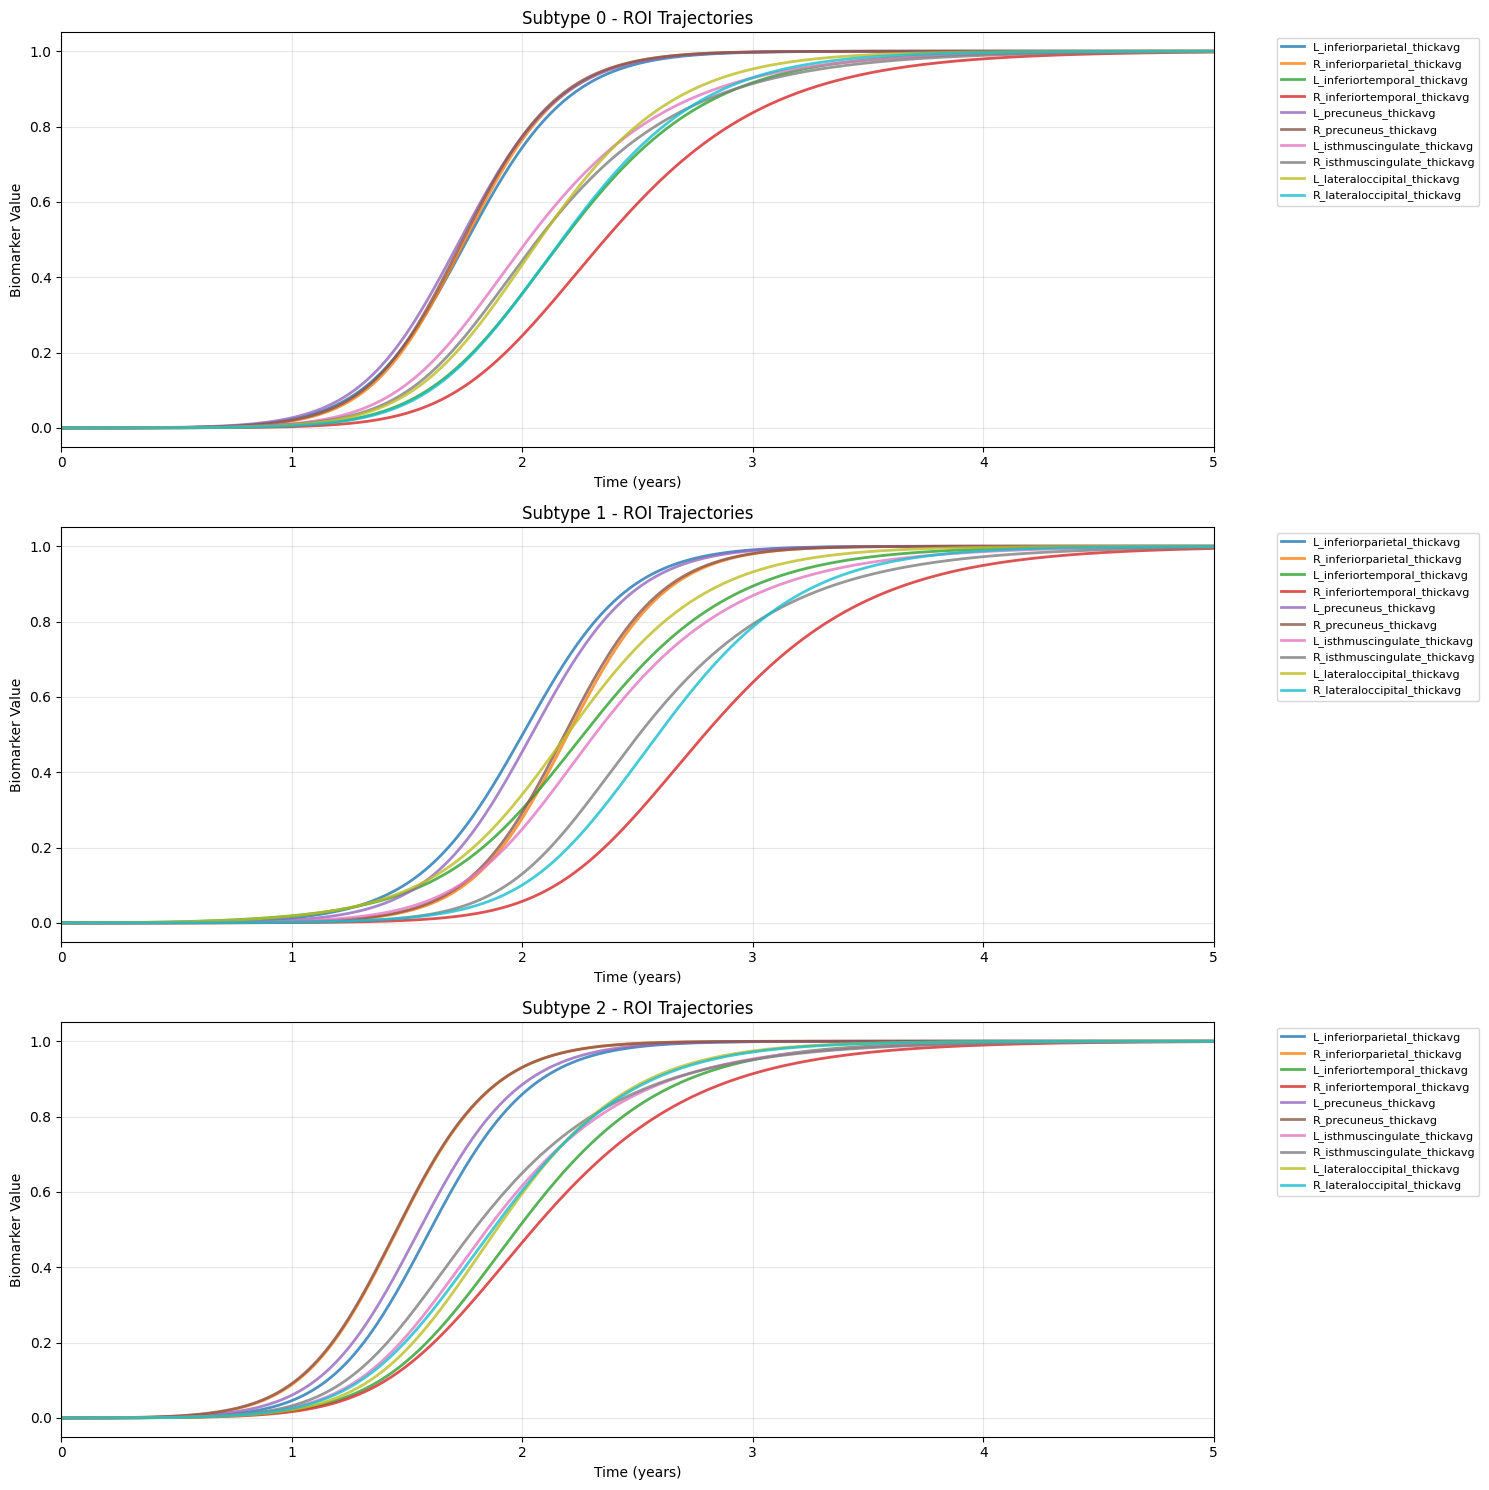

In [31]:
# ROI Subplots: 10 ROI trajectories for each subtype
cluster_f = best_data["cluster_f"]
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]

ROI = [6, 40, 7, 41, 23, 57, 8, 42, 9, 43]
ROI_names = [biomarker_names[i] for i in ROI]

final_scalar_K = best_data["final_scalar_K"]
final_s = best_data["final_s"]
final_kappa = best_data["final_kappa"]

fig, axes = plt.subplots(n_subtypes, 1, figsize=(15, 5 * n_subtypes))
if n_subtypes == 1:
    axes = [axes]

for subtype in range(n_subtypes):
    f_subtype = cluster_f[subtype]
    x0 = np.zeros(n_biomarkers)
    Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K, final_kappa)

    ax = axes[subtype]
    for i, roi_idx in enumerate(ROI):
        ax.plot(t_span, Xtraj_subtype[roi_idx], label=ROI_names[i], linewidth=2, alpha=0.8)

    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Biomarker Value")
    ax.set_title(f"Subtype {subtype} - ROI Trajectories")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 5)

plt.tight_layout()
plt.show()

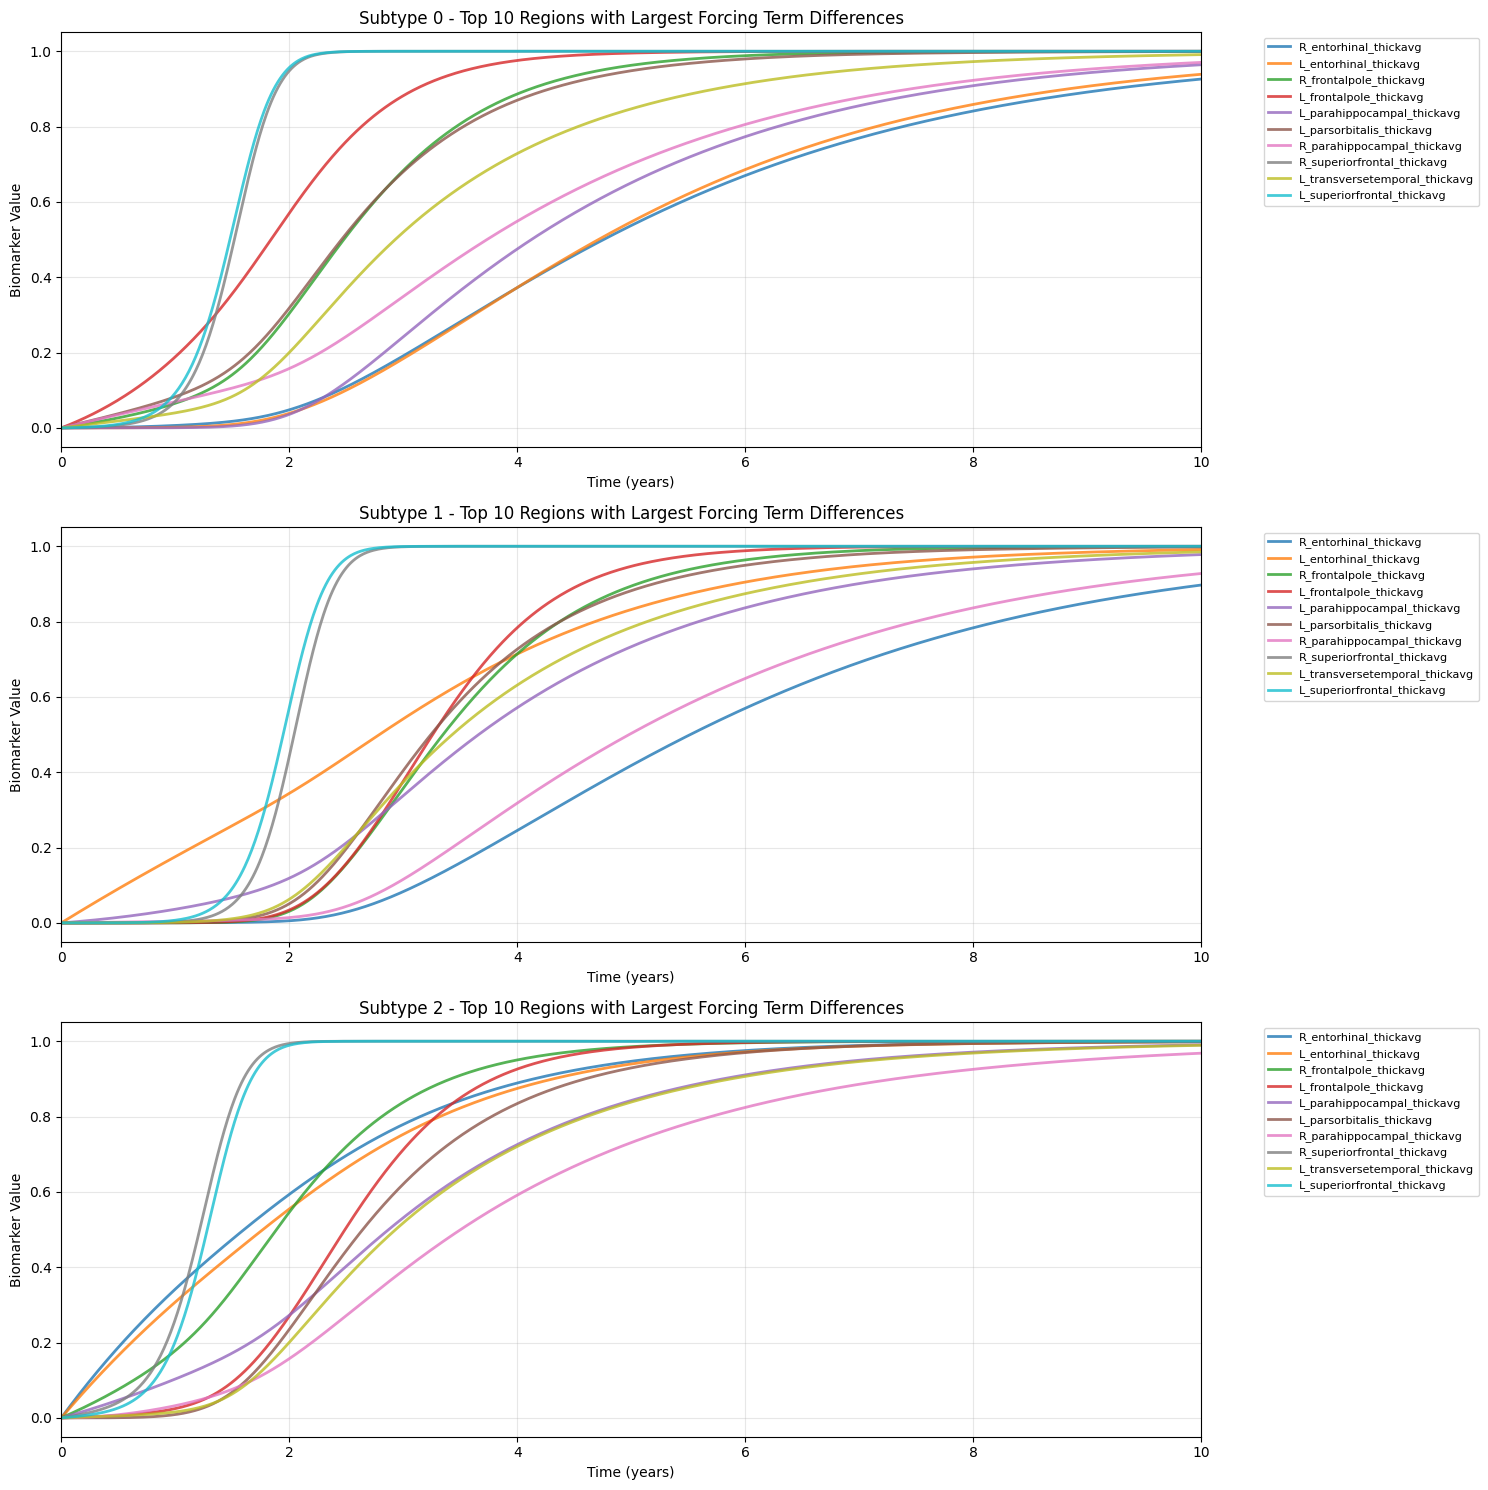

In [32]:
# ROI Subplots: Top 10 regions with largest forcing term differences

cluster_f = best_data["cluster_f"] # (n_subtypes, n_biomarkers)
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]

# Per-ROI difference across all subtypes (works for any n_subtypes)
f_diff_max = np.zeros(n_biomarkers)
for i in range(n_subtypes):
    for j in range(i + 1, n_subtypes):
        f_diff_max = np.maximum(f_diff_max, np.abs(cluster_f[i] - cluster_f[j]))

top_n = 10
top_indices = np.argsort(f_diff_max)[-top_n:][::-1]
top_ROI_names = [biomarker_names[idx] for idx in top_indices]

final_scalar_K = best_data["final_scalar_K"]
final_s = best_data["final_s"]
final_kappa = best_data["final_kappa"]

# Plot trajectories for each subtype
fig, axes = plt.subplots(n_subtypes, 1, figsize=(15, 5 * n_subtypes))
if n_subtypes == 1:
    axes = [axes]

for subtype in range(n_subtypes):
    f_subtype = cluster_f[subtype]
    x0 = np.zeros(n_biomarkers)
    Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K, final_kappa)

    ax = axes[subtype]
    for i, roi_idx in enumerate(top_indices):
        ax.plot(t_span, Xtraj_subtype[roi_idx], label=top_ROI_names[i], linewidth=2, alpha=0.8)

    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Biomarker Value")
    ax.set_title(f"Subtype {subtype} - Top 10 Regions with Largest Forcing Term Differences")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)
    ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()

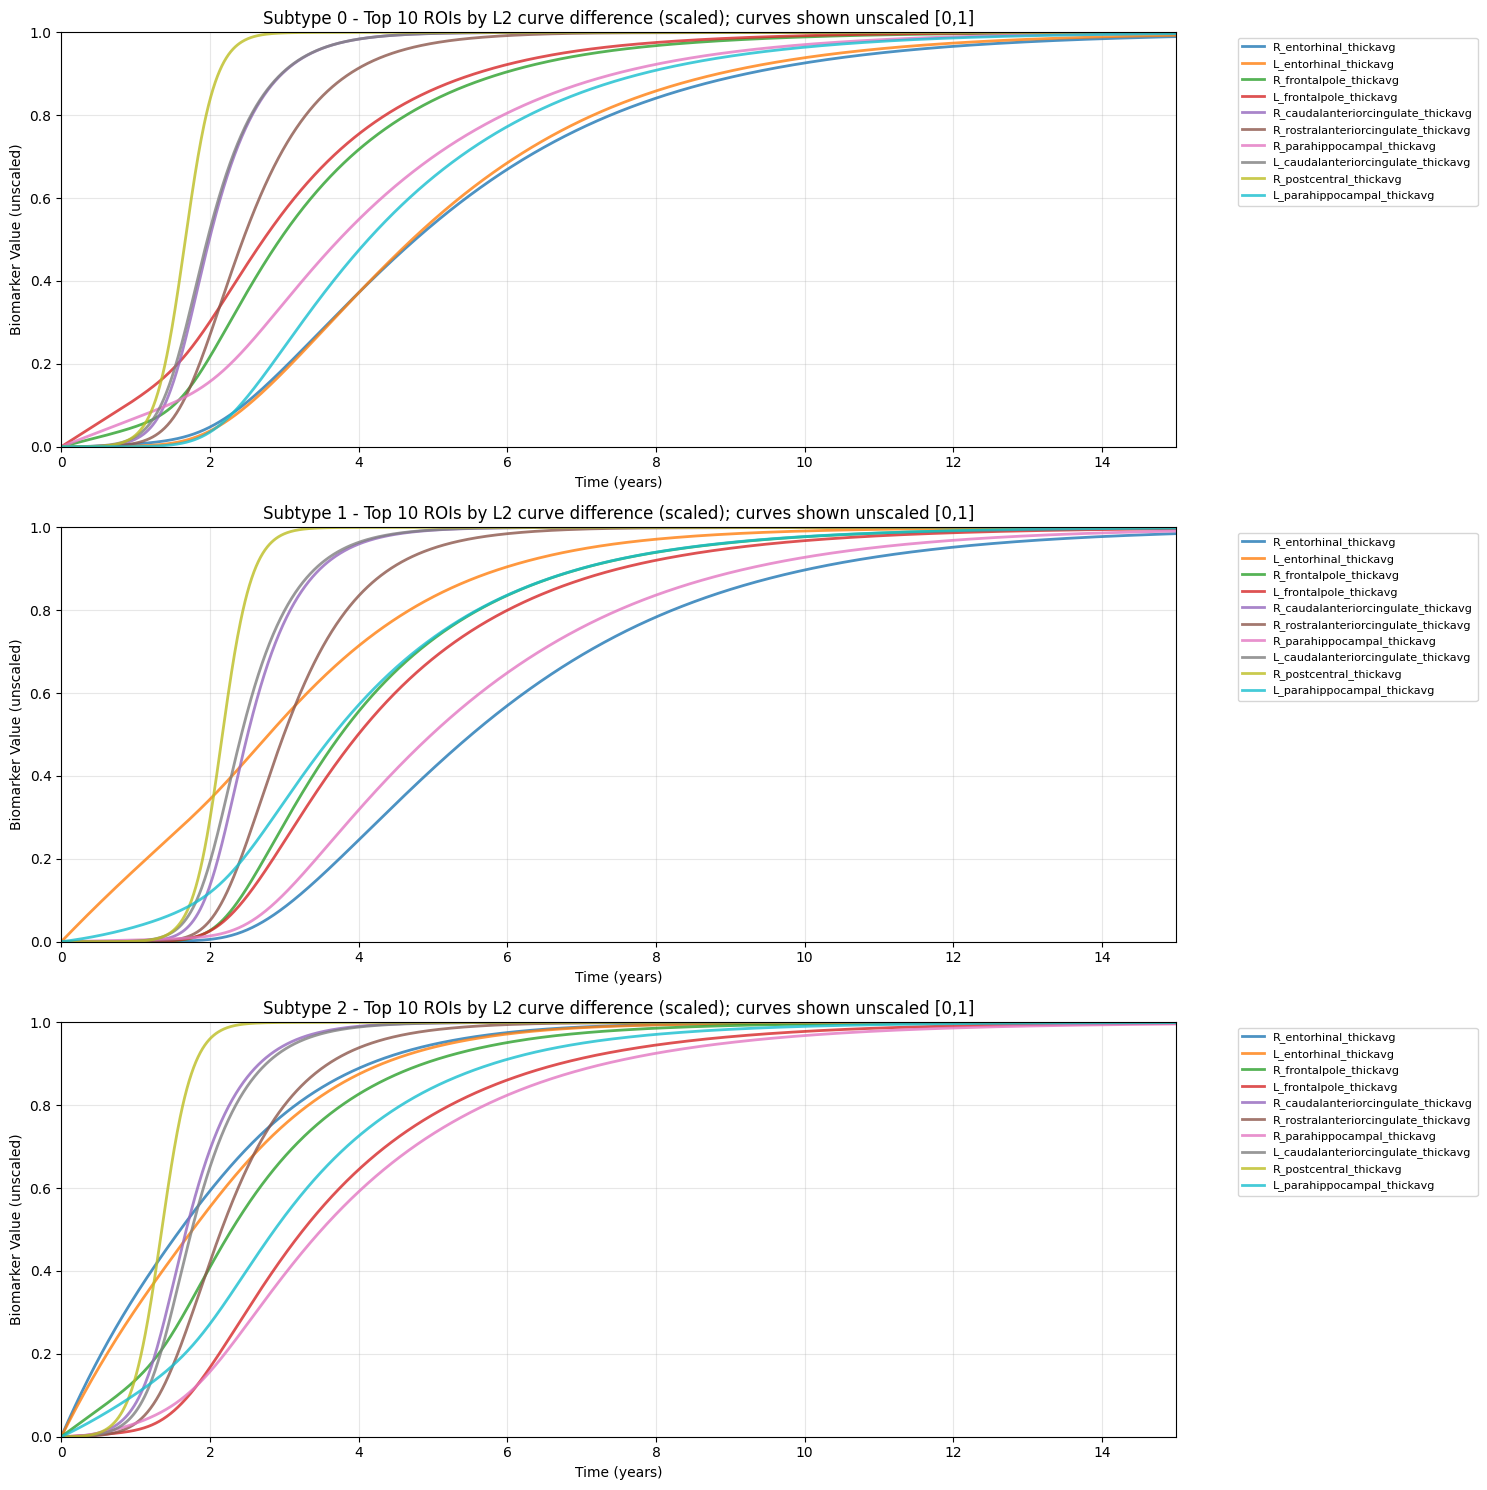

In [33]:
# Top 10 ROIs by largest L2 difference in *scaled* trajectories between subtypes
cluster_f = best_data["cluster_f"]
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]
final_scalar_K = best_data["final_scalar_K"]
final_s = best_data["final_s"]

# Scaled trajectories (for comparison / selection)
trajs_scaled = []
# Unscaled trajectories (for plotting, bounded in [0,1])
trajs_unscaled = []
for k in range(n_subtypes):
    x0 = np.zeros(n_biomarkers)
    X_k = solve_system(x0, cluster_f[k], K, t_span, final_scalar_K)
    trajs_unscaled.append(X_k)
    trajs_scaled.append(final_s[:, None] * X_k)
trajs_scaled = np.array(trajs_scaled)
trajs_unscaled = np.array(trajs_unscaled)

# Per-biomarker: max over subtype pairs of L2 distance between *scaled* curves
dt_span = np.diff(t_span)
if len(dt_span) == 0:
    dt_span = np.array([1.0])
else:
    dt_span = np.concatenate([dt_span, [dt_span[-1]]])
curve_l2_max = np.zeros(n_biomarkers)
for b in range(n_biomarkers):
    for i in range(n_subtypes):
        for j in range(i + 1, n_subtypes):
            diff = trajs_scaled[i, b, :] - trajs_scaled[j, b, :]
            l2 = np.sqrt(np.sum(diff ** 2 * dt_span))
            curve_l2_max[b] = max(curve_l2_max[b], l2)

top_n = 10
top_indices = np.argsort(curve_l2_max)[-top_n:][::-1]
top_ROI_names = [biomarker_names[idx] for idx in top_indices]

# Plot *unscaled* trajectories (bounded [0,1]) for each subtype
fig, axes = plt.subplots(n_subtypes, 1, figsize=(15, 5 * n_subtypes))
if n_subtypes == 1:
    axes = [axes]

for subtype in range(n_subtypes):
    ax = axes[subtype]
    for i, roi_idx in enumerate(top_indices):
        ax.plot(t_span, trajs_unscaled[subtype, roi_idx, :], label=top_ROI_names[i], linewidth=2, alpha=0.8)
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Biomarker Value (unscaled)")
    ax.set_title(f"Subtype {subtype} - Top 10 ROIs by L2 curve difference (scaled); curves shown unscaled [0,1]")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)
    ax.set_xlim(0, 15)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

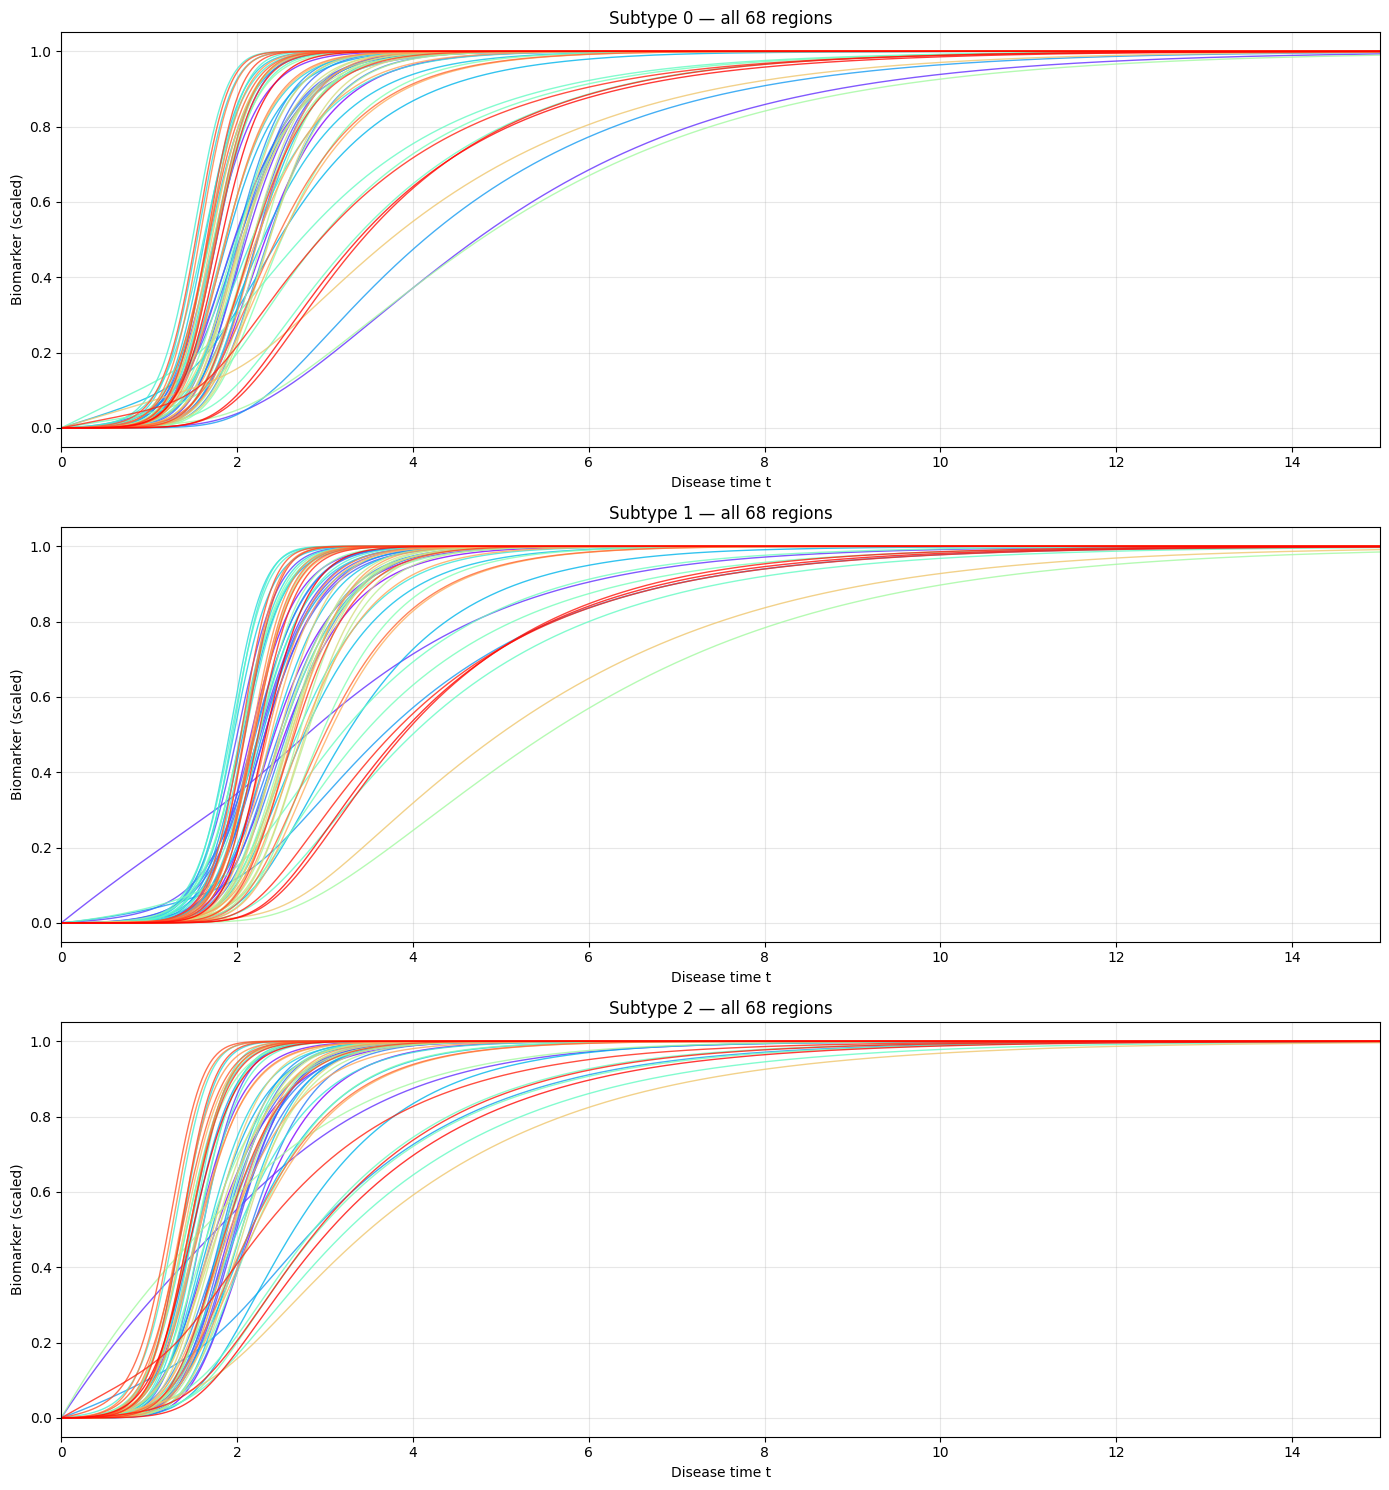

In [34]:
# Plot all 68 brain regions for each subtype (no legend; max-distinct colors)
import numpy as np
import matplotlib.pyplot as plt
from COMIND_transformer.utils import solve_system

cluster_f = best_data["cluster_f"]
final_s = best_data["final_s"]
final_scalar_K = best_data["final_scalar_K"]
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]

# 68 distinct colors (rainbow-like)
colors = plt.cm.rainbow(np.linspace(0, 1, n_biomarkers))

fig, axes = plt.subplots(n_subtypes, 1, figsize=(14, 5 * n_subtypes))
if n_subtypes == 1:
    axes = [axes]
for subtype, ax in enumerate(axes):
    f_subtype = np.ravel(cluster_f[subtype])
    x0 = np.zeros(n_biomarkers)
    Xtraj = solve_system(x0, f_subtype, K, t_span, final_scalar_K)
    for b in range(n_biomarkers):
        traj = Xtraj[b] #* final_s[b]
        ax.plot(t_span, traj, color=colors[b], alpha=0.8, linewidth=1)
    ax.set_xlabel("Disease time t")
    ax.set_ylabel("Biomarker (scaled)")
    ax.set_title(f"Subtype {subtype} — all {n_biomarkers} regions")
    ax.set_xlim(0, 15)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


CONTINGENCY TABLE: Discovered Subtypes vs Clinical Subgroups
Clinical Subgroup   Non-Sporadic PD  Sporadic PD
Discovered Subtype                              
0                                 7           53
1                                 3           35
2                                 2           46


<Figure size 1000x600 with 0 Axes>

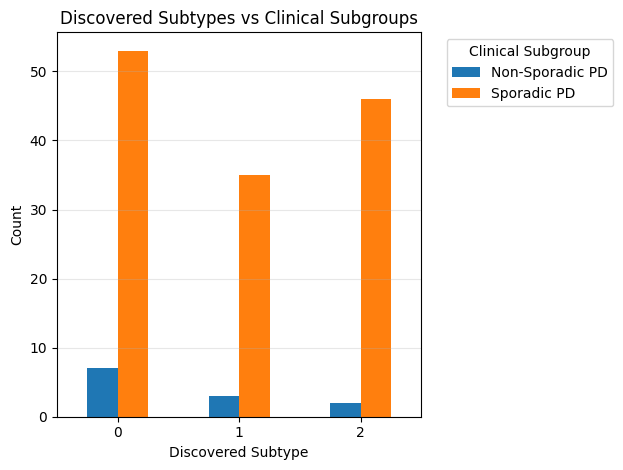

In [35]:
# Clinical Subgroup Comparison: Sporadic PD vs Non-Sporadic PD
unique_pids = np.unique(ids_valid)
pid_to_subgroup = {}
for pid in unique_pids:
    mask = df['subj_id'] == pid
    if mask.sum() > 0:
        subgroups = df.loc[mask, 'subgroup'].dropna().unique()
        if len(subgroups) > 0:
            pid_to_subgroup[pid] = subgroups[0] if len(subgroups) == 1 else df.loc[mask, 'subgroup'].mode()[0]

# Map to our assignments
subgroup_per_patient = np.array([pid_to_subgroup.get(pid, 'Unknown') for pid in unique_pids])
assignment_per_patient = np.array([pid_to_assignment.get(pid, -1) for pid in unique_pids])

# Create binary classification: Sporadic PD vs Non-Sporadic PD
sporadic_mask = np.array([sg == 'Sporadic PD' if isinstance(sg, str) else False for sg in subgroup_per_patient])
clinical_subgroup = np.where(sporadic_mask, 'Sporadic PD', 'Non-Sporadic PD')

# Create contingency table
contingency = pd.crosstab(
    pd.Series(assignment_per_patient, name='Discovered Subtype'),
    pd.Series(clinical_subgroup, name='Clinical Subgroup')
)
print("\nCONTINGENCY TABLE: Discovered Subtypes vs Clinical Subgroups")
print(contingency)

plt.figure(figsize=(10, 6))
contingency.plot(kind='bar', stacked=False)
plt.title('Discovered Subtypes vs Clinical Subgroups')
plt.xlabel('Discovered Subtype')
plt.ylabel('Count')
plt.legend(title='Clinical Subgroup', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



Subtype 0 Beta Statistics:
  Mean: 9.2787
  Median: 5.6328
  Std: 7.3741

Subtype 1 Beta Statistics:
  Mean: 11.7601
  Median: 7.3273
  Std: 8.8952

Subtype 2 Beta Statistics:
  Mean: 14.8028
  Median: 17.0666
  Std: 8.2529


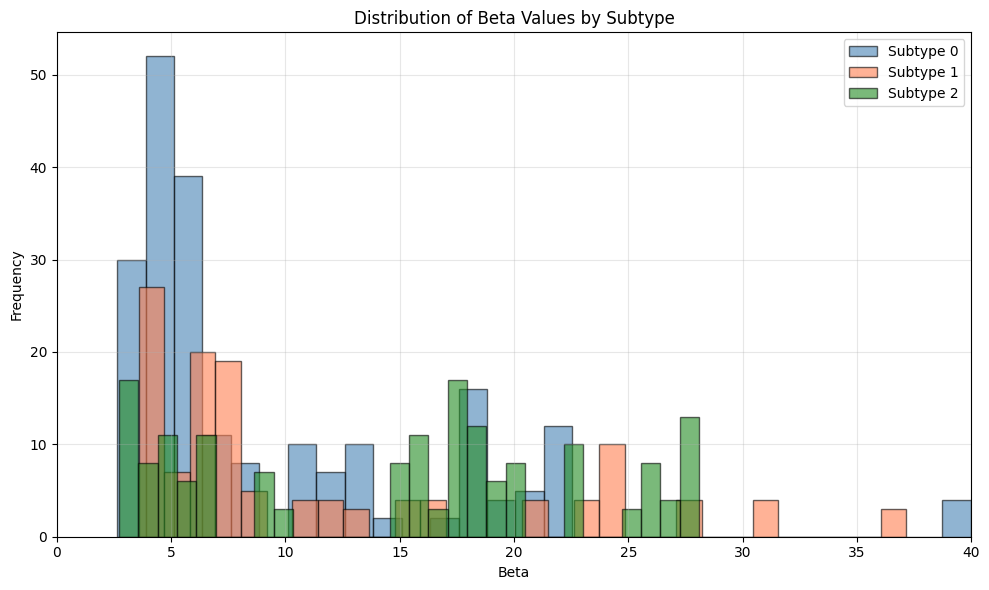

In [36]:
# Beta distributions by subtype
plt.figure(figsize=(10, 6))
colors = ['steelblue', 'coral', 'forestgreen', 'purple']
for subtype in range(n_subtypes):
    beta_subtype = beta_valid[assignment_valid == subtype]
    plt.hist(beta_subtype, bins=30, alpha=0.6, label=f'Subtype {subtype}', 
             color=colors[subtype], edgecolor='black')
    print(f"\nSubtype {subtype} Beta Statistics:")
    print(f"  Mean: {np.mean(beta_subtype):.4f}")
    print(f"  Median: {np.median(beta_subtype):.4f}")
    print(f"  Std: {np.std(beta_subtype):.4f}")

plt.xlabel("Beta")
plt.ylabel("Frequency")
plt.title("Distribution of Beta Values by Subtype")
plt.xlim(0, 40)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


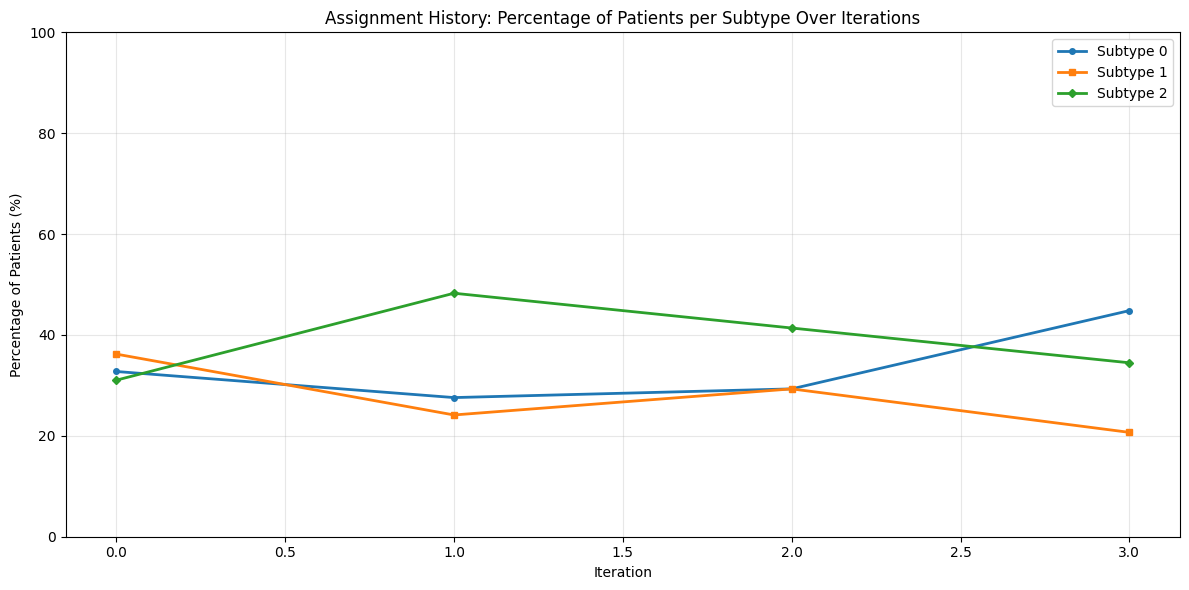

In [37]:
# Plot assignment history over iterations for any number of subtypes
if "assignment_history" in best_data.files:
    assignment_history = best_data["assignment_history"]  # (n_patients, n_iterations+1)
    n_iterations = assignment_history.shape[1] - 1

    # Determine all subtypes that ever appear
    unique_subtypes = np.unique(assignment_history)
    unique_subtypes = np.sort(unique_subtypes)

    # For each subtype, compute its percentage over iterations
    pct_per_subtype = {k: [] for k in unique_subtypes}

    for iter_idx in range(n_iterations + 1):
        assignments_iter = assignment_history[:, iter_idx]
        n_patients = len(assignments_iter)
        for k in unique_subtypes:
            n_k = np.sum(assignments_iter == k)
            pct_per_subtype[k].append(100 * n_k / n_patients)

    # Plot
    plt.figure(figsize=(12, 6))
    iterations = np.arange(n_iterations + 1)

    markers = ['o', 's', 'D', '^', 'v', 'x', '*', 'P', 'X']  # cycle markers if many subtypes
    for idx, k in enumerate(unique_subtypes):
        marker = markers[idx % len(markers)]
        plt.plot(
            iterations,
            pct_per_subtype[k],
            label=f'Subtype {k}',
            linewidth=2,
            marker=marker,
            markersize=4,
        )

    plt.xlabel('Iteration')
    plt.ylabel('Percentage of Patients (%)')
    plt.title('Assignment History: Percentage of Patients per Subtype Over Iterations')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

Overall agreement between 'with cog' and 'no cog': 100.0% (30/30 patients)
Patients who changed subtype: 0/30

=== Agreement by Clinical Variable ===
(Shown as: patients with agreement / total validation patients (30))
Clinical Subtype:
  Non-Sporadic PD: 2/30
  Sporadic PD: 28/30

MoCA:
  18–25: 9/30
  ≤17: 2/30
  26–30: 19/30

NSD:
  NSD 1–2: 3/30
  NSD 3: 17/30
  NSD 4+: 8/30
  No NSD: 2/30

HY:
  HY 2: 20/30
  HY 1: 7/30
  HY 3: 3/30


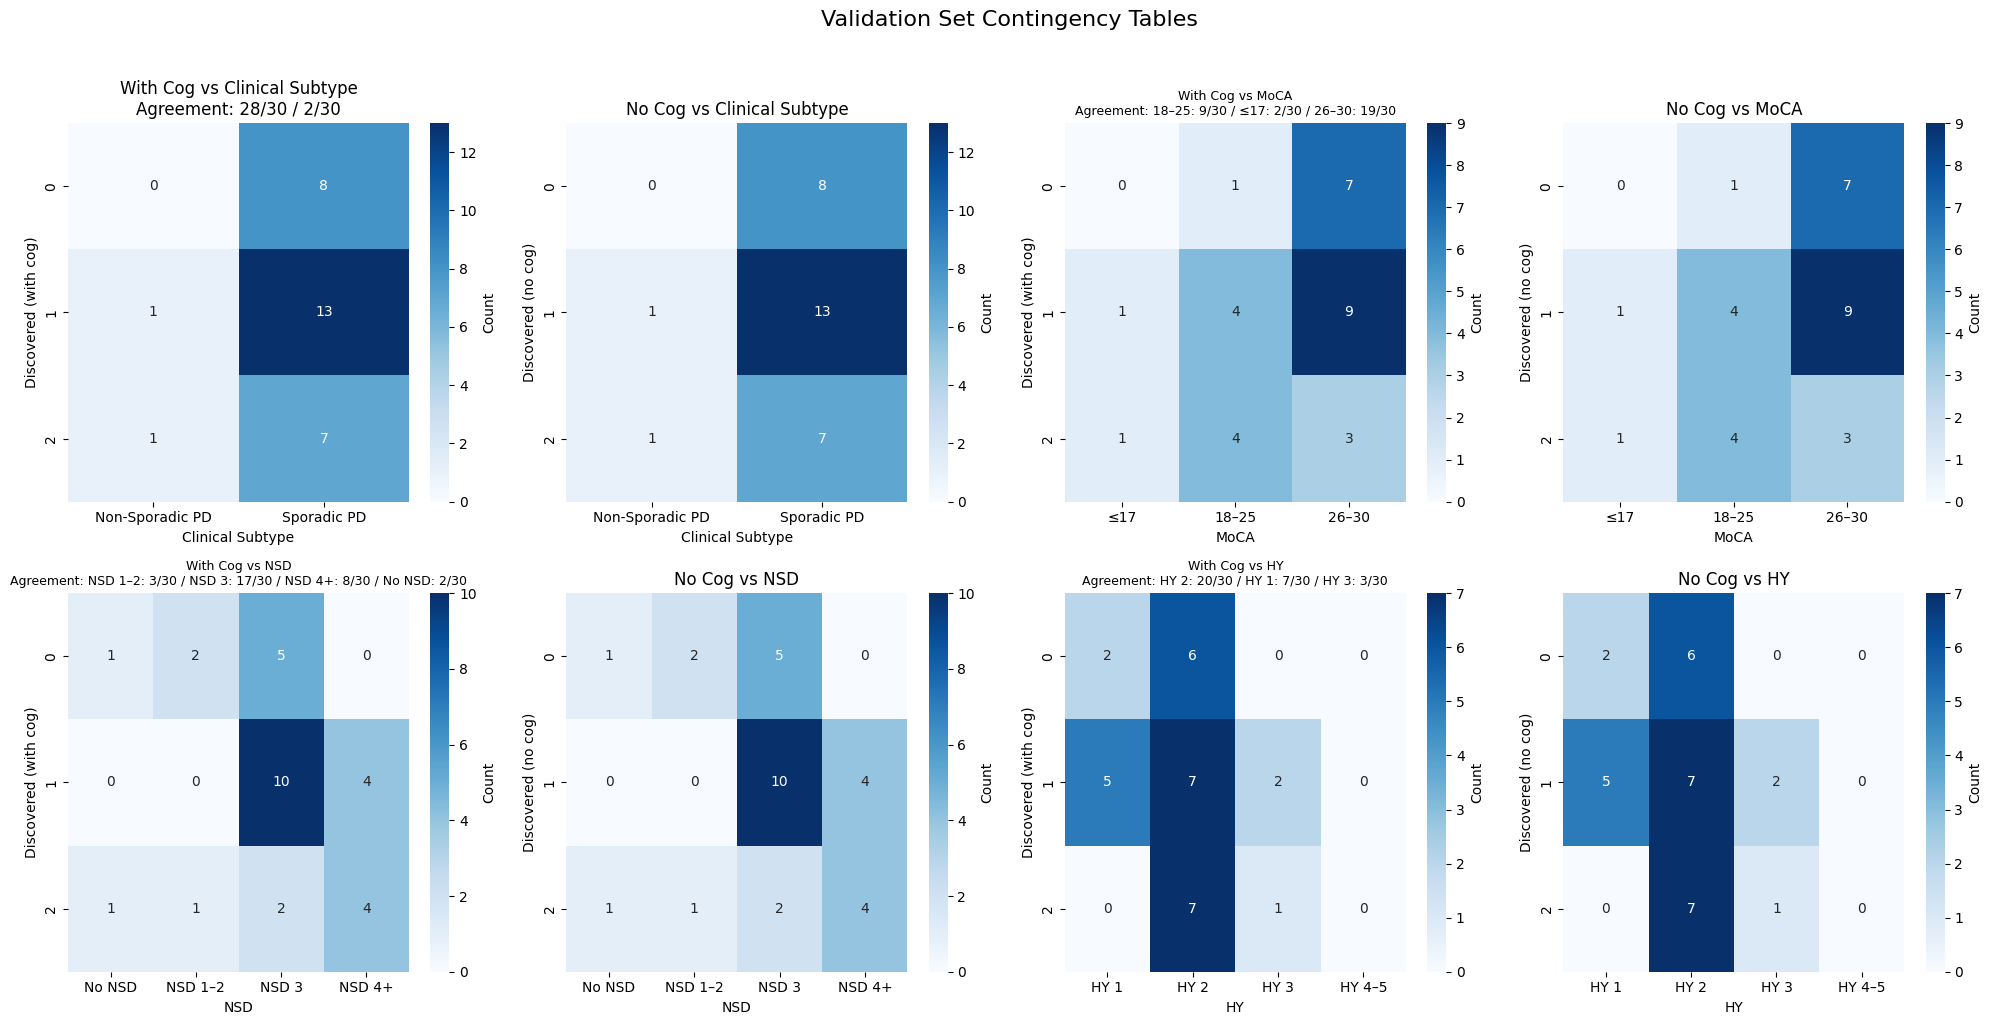

In [38]:
# Validation set contingency tables with visualizations
val_ids = best_data["val_ids"]
val_assignments_with_cog = best_data['val_assignments_with_cog']
val_assignments_no_cog = best_data['val_assignments_no_cog']

# Calculate overall agreement (same subtype assignment regardless of which subtype)
agreements = [val_assignments_with_cog[i] == val_assignments_no_cog[i] for i in range(len(val_ids))]
agreement_pct = 100 * np.mean(agreements)
n_agree = np.sum(agreements)
n_disagree = len(val_ids) - n_agree
print(f"Overall agreement between 'with cog' and 'no cog': {agreement_pct:.1f}% ({n_agree}/{len(val_ids)} patients)")
print(f"Patients who changed subtype: {n_disagree}/{len(val_ids)}")

# Get clinical variables per patient using FINAL observation (most recent time point)
pid_to_clinical = {}
pid_to_moca = {}
pid_to_nsd = {}
pid_to_hy = {}

for pid in val_ids:
    mask = df['subj_id'] == pid
    patient_df = df.loc[mask].copy()
    
    # Get final observation (maximum time)
    final_idx = patient_df['time'].idxmax()
    final_row = patient_df.loc[final_idx]
    
    # Clinical subtype
    subgroup = final_row['subgroup']
    pid_to_clinical[pid] = 'Sporadic PD' if subgroup == 'Sporadic PD' else 'Non-Sporadic PD'
    
    # Clinical scores from final observation
    pid_to_moca[pid] = final_row['MCATOT']
    pid_to_nsd[pid] = final_row['NSD_STAGE']
    pid_to_hy[pid] = final_row['NHY']

# Prepare data with proper binning
clinical = [pid_to_clinical[pid] for pid in val_ids]

# MoCA: ≤17, 18–25, 26–30 (typical clinical-style cutoffs)
moca_binned = []
for pid in val_ids:
    m = pid_to_moca[pid]
    if np.isnan(m):
        moca_binned.append('Missing')
    elif m < 18:
        moca_binned.append('≤17')
    elif m < 26:
        moca_binned.append('18–25')
    else:
        moca_binned.append('26–30')

# NSD: No NSD (0), NSD 1–2, NSD 3, NSD 4+
nsd_binned = []
for pid in val_ids:
    n = pid_to_nsd[pid]
    if np.isnan(n) or n == 0:
        nsd_binned.append('No NSD')
    elif n in (1, 2):
        nsd_binned.append('NSD 1–2')
    elif n == 3:
        nsd_binned.append('NSD 3')
    else:
        nsd_binned.append('NSD 4+')

# HY: HY 1, HY 2, HY 3, HY 4–5
hy_binned = []
for pid in val_ids:
    h = pid_to_hy[pid]
    if h <= 1:
        hy_binned.append('HY 1')
    elif h <= 2:
        hy_binned.append('HY 2')
    elif h <= 3:
        hy_binned.append('HY 3')
    else:
        hy_binned.append('HY 4–5')

# Calculate agreement for each clinical variable category (same vs different subtype)
def calc_agreement_by_category(categories, assignments_with, assignments_no, total_patients):
    agreement_by_cat = {}
    for cat in set(categories):
        mask = [c == cat for c in categories]
        if sum(mask) > 0:
            with_cat = [assignments_with[i] for i in range(len(mask)) if mask[i]]
            no_cat = [assignments_no[i] for i in range(len(mask)) if mask[i]]
            agreements = [with_cat[i] == no_cat[i] for i in range(len(with_cat))]
            n_agree = np.sum(agreements)
            agreement_by_cat[cat] = f"{n_agree}/{total_patients}"
    return agreement_by_cat

total_val_patients = len(val_ids)
clinical_agreement = calc_agreement_by_category(clinical, val_assignments_with_cog, val_assignments_no_cog, total_val_patients)
moca_agreement = calc_agreement_by_category(moca_binned, val_assignments_with_cog, val_assignments_no_cog, total_val_patients)
nsd_agreement = calc_agreement_by_category(nsd_binned, val_assignments_with_cog, val_assignments_no_cog, total_val_patients)
hy_agreement = calc_agreement_by_category(hy_binned, val_assignments_with_cog, val_assignments_no_cog, total_val_patients)

print("\n=== Agreement by Clinical Variable ===")
print(f"(Shown as: patients with agreement / total validation patients ({total_val_patients}))")
print("Clinical Subtype:")
for cat, ag in clinical_agreement.items():
    print(f"  {cat}: {ag}")
print("\nMoCA:")
for cat, ag in moca_agreement.items():
    print(f"  {cat}: {ag}")
print("\nNSD:")
for cat, ag in nsd_agreement.items():
    print(f"  {cat}: {ag}")
print("\nHY:")
for cat, ag in hy_agreement.items():
    print(f"  {cat}: {ag}")

# Create visualizations
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Validation Set Contingency Tables', fontsize=16, y=1.02)

# 1. With cog vs Clinical
ct1 = pd.crosstab(pd.Series(val_assignments_with_cog, name='Discovered (with cog)'), 
                  pd.Series(clinical, name='Clinical Subtype'))
sns.heatmap(ct1, annot=True, fmt='d', cmap='Blues', ax=axes[0,0], cbar_kws={'label': 'Count'})
axes[0,0].set_title(f'With Cog vs Clinical Subtype\nAgreement: {clinical_agreement.get("Sporadic PD", "N/A")} / {clinical_agreement.get("Non-Sporadic PD", "N/A")}')

# 2. No cog vs Clinical
ct2 = pd.crosstab(pd.Series(val_assignments_no_cog, name='Discovered (no cog)'), 
                  pd.Series(clinical, name='Clinical Subtype'))
sns.heatmap(ct2, annot=True, fmt='d', cmap='Blues', ax=axes[0,1], cbar_kws={'label': 'Count'})
axes[0,1].set_title('No Cog vs Clinical Subtype')

# 3. With cog vs MoCA
ct3 = pd.crosstab(pd.Series(val_assignments_with_cog, name='Discovered (with cog)'), 
                  pd.Series(moca_binned, name='MoCA'))
for bin_name in ['≤17', '18–25', '26–30', 'Missing']:
    if bin_name not in ct3.columns:
        ct3[bin_name] = 0
ct3 = ct3[['≤17', '18–25', '26–30']]
sns.heatmap(ct3, annot=True, fmt='d', cmap='Blues', ax=axes[0,2], cbar_kws={'label': 'Count'})
moca_title = 'With Cog vs MoCA\nAgreement: ' + ' / '.join([f"{k}: {v}" for k, v in moca_agreement.items()])
axes[0,2].set_title(moca_title, fontsize=9)

# 4. No cog vs MoCA
ct4 = pd.crosstab(pd.Series(val_assignments_no_cog, name='Discovered (no cog)'), 
                  pd.Series(moca_binned, name='MoCA'))
for bin_name in ['≤17', '18–25', '26–30']:
    if bin_name not in ct4.columns:
        ct4[bin_name] = 0
ct4 = ct4[['≤17', '18–25', '26–30']]
sns.heatmap(ct4, annot=True, fmt='d', cmap='Blues', ax=axes[0,3], cbar_kws={'label': 'Count'})
axes[0,3].set_title('No Cog vs MoCA')

# 5. With cog vs NSD
ct5 = pd.crosstab(pd.Series(val_assignments_with_cog, name='Discovered (with cog)'), 
                  pd.Series(nsd_binned, name='NSD'))
for cat in ['No NSD', 'NSD 1–2', 'NSD 3', 'NSD 4+']:
    if cat not in ct5.columns:
        ct5[cat] = 0
ct5 = ct5[['No NSD', 'NSD 1–2', 'NSD 3', 'NSD 4+']]
sns.heatmap(ct5, annot=True, fmt='d', cmap='Blues', ax=axes[1,0], cbar_kws={'label': 'Count'})
nsd_title = 'With Cog vs NSD\nAgreement: ' + ' / '.join([f"{k}: {v}" for k, v in nsd_agreement.items()])
axes[1,0].set_title(nsd_title, fontsize=9)

# 6. No cog vs NSD
ct6 = pd.crosstab(pd.Series(val_assignments_no_cog, name='Discovered (no cog)'), 
                  pd.Series(nsd_binned, name='NSD'))
for cat in ['No NSD', 'NSD 1–2', 'NSD 3', 'NSD 4+']:
    if cat not in ct6.columns:
        ct6[cat] = 0
ct6 = ct6[['No NSD', 'NSD 1–2', 'NSD 3', 'NSD 4+']]
sns.heatmap(ct6, annot=True, fmt='d', cmap='Blues', ax=axes[1,1], cbar_kws={'label': 'Count'})
axes[1,1].set_title('No Cog vs NSD')

# 7. With cog vs HY
ct7 = pd.crosstab(pd.Series(val_assignments_with_cog, name='Discovered (with cog)'), 
                  pd.Series(hy_binned, name='HY'))
for cat in ['HY 1', 'HY 2', 'HY 3', 'HY 4–5']:
    if cat not in ct7.columns:
        ct7[cat] = 0
ct7 = ct7[['HY 1', 'HY 2', 'HY 3', 'HY 4–5']]
sns.heatmap(ct7, annot=True, fmt='d', cmap='Blues', ax=axes[1,2], cbar_kws={'label': 'Count'})
hy_title = 'With Cog vs HY\nAgreement: ' + ' / '.join([f"{k}: {v}" for k, v in hy_agreement.items()])
axes[1,2].set_title(hy_title, fontsize=9)

# 8. No cog vs HY
ct8 = pd.crosstab(pd.Series(val_assignments_no_cog, name='Discovered (no cog)'), 
                  pd.Series(hy_binned, name='HY'))
for cat in ['HY 1', 'HY 2', 'HY 3', 'HY 4–5']:
    if cat not in ct8.columns:
        ct8[cat] = 0
ct8 = ct8[['HY 1', 'HY 2', 'HY 3', 'HY 4–5']]
sns.heatmap(ct8, annot=True, fmt='d', cmap='Blues', ax=axes[1,3], cbar_kws={'label': 'Count'})
axes[1,3].set_title('No Cog vs HY')

plt.tight_layout()
plt.show()

Counts: TD/PIGD (first visit) vs Discovered subtype

Subtype                 0   1   2  Total
TD/PIGD (first visit)                   
Indeterminate           5   4   4     13
PIGD                   34  16  21     71
TD                     21  18  23     62
Total                  60  38  48    146


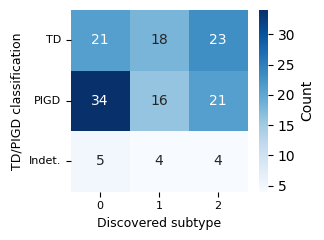

In [39]:
df = df.copy()
df["TD_mean"] = df["TD_score"] / 10
df["PIGD_mean"] = df["PIGD_score"] / 3
df["TD_PIGD_ratio"] = np.where(
    df["PIGD_mean"] == 0,
    np.inf,
    df["TD_mean"] / df["PIGD_mean"],
)
conditions = [
    (df["TD_PIGD_ratio"] >= 1.5),
    (df["TD_mean"] > 0) & (df["PIGD_mean"] == 0),
    (df["TD_PIGD_ratio"] <= 1.0),
    (df["TD_mean"] == 0) & (df["PIGD_mean"] > 0),
]
values = ["TD", "TD", "PIGD", "PIGD"]
df["TD_PIGD_Classification"] = np.select(conditions, values, default="Indeterminate")

# get first time point per patient
first_visit = df.loc[df.groupby("subj_id")["time"].idxmax()].copy()
first_visit = first_visit[["subj_id", "time", "TD_PIGD_Classification"]].copy()

# get discovered subtype
first_visit["discovered_subtype"] = first_visit["subj_id"].map(pid_to_assignment)
first_visit = first_visit[first_visit["discovered_subtype"] >= 0].copy()

# Confusion matrix: TD/PIGD at final visit vs discovered subtype
confusion = pd.crosstab(
    first_visit["TD_PIGD_Classification"],
    first_visit["discovered_subtype"],
    margins=True,
    margins_name="Total",
)
confusion.index.name = "TD/PIGD (first visit)"
confusion.columns.name = "Subtype"
print("Counts: TD/PIGD (first visit) vs Discovered subtype\n")
print(confusion)

# Heatmap (counts only, no margin row/col for plot)
plot_mat = pd.crosstab(
    first_visit["TD_PIGD_Classification"],
    first_visit["discovered_subtype"],
)
# Optional: order rows as TD, PIGD, Indeterminate
for label in ["TD", "PIGD", "Indeterminate"]:
    if label not in plot_mat.index:
        plot_mat.loc[label] = 0
plot_mat = plot_mat.reindex([c for c in ["TD", "PIGD", "Indeterminate"] if c in plot_mat.index])
plot_mat = plot_mat.sort_index(axis=1)

fig, ax = plt.subplots(figsize=(3.3, 2.5))
sns.heatmap(
    plot_mat,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    cbar_kws={"label": "Count"},
)

# Shorter y-tick labels: TD, PIGD, Indet.
ax.set_yticklabels(["TD", "PIGD", "Indet."], fontsize=8)

ax.set_xlabel("Discovered subtype", fontsize=9)
ax.set_ylabel("TD/PIGD classification", fontsize=9)
ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.savefig("td_pigd_vs_subtype.pdf", bbox_inches="tight", dpi=300)
plt.show()

Validation: Kendall τ (β vs first NHY) = -0.0032, p = 0.9833  (n = 30)
Validation: Kendall τ (β vs first NSD) = 0.0031, p = 0.9834  (n = 29)


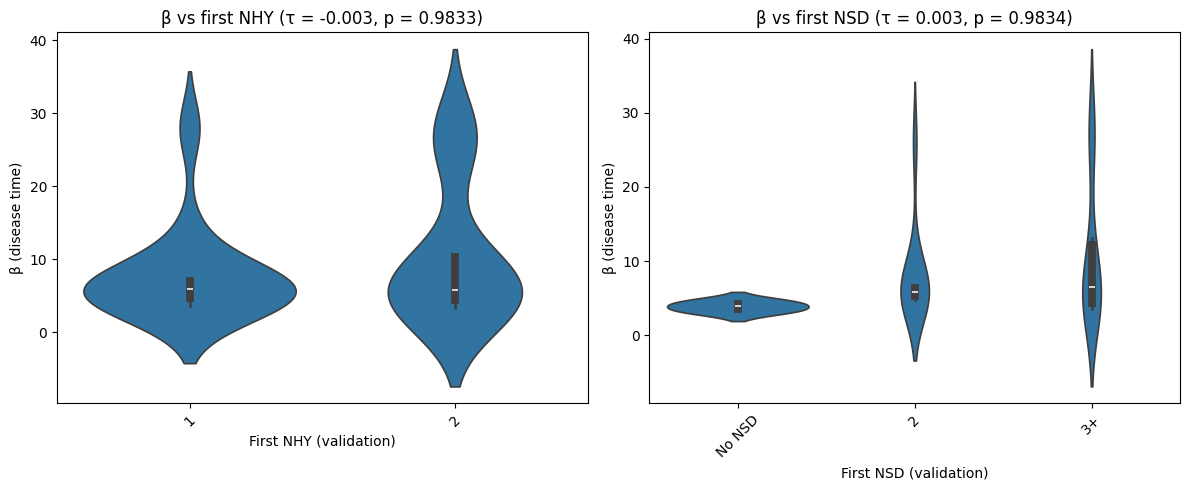

In [40]:
# Best model: Kendall tau (validation beta vs first NHY, first NSD) + violin plots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kendalltau

val_ids = best_data["val_ids"]
beta_val = best_data["beta_val_with_cog"] if "beta_val_with_cog" in best_data.files else best_data["beta_val"]

# First NHY and first NSD per validation patient (earliest time point)
pid_to_nhy_first = {}
pid_to_nsd_first = {}
for pid in val_ids:
    mask = df["subj_id"] == pid
    patient_df = df.loc[mask].copy()
    if len(patient_df) == 0:
        pid_to_nhy_first[pid] = np.nan
        pid_to_nsd_first[pid] = np.nan
        continue
    first_idx = patient_df["time"].idxmin()
    pid_to_nhy_first[pid] = patient_df.loc[first_idx, "NHY"]
    pid_to_nsd_first[pid] = patient_df.loc[first_idx, "NSD_STAGE"]

beta_vals = np.asarray(beta_val, dtype=float)
nhy_first_vals = np.array([pid_to_nhy_first[pid] for pid in val_ids], dtype=float)
nsd_first_vals = np.array([pid_to_nsd_first[pid] for pid in val_ids], dtype=float)

# Kendall tau: beta vs first NHY
valid_nhy = np.isfinite(beta_vals) & np.isfinite(nhy_first_vals)
if np.sum(valid_nhy) >= 2:
    tau_nhy, p_nhy = kendalltau(beta_vals[valid_nhy], nhy_first_vals[valid_nhy])
    print(f"Validation: Kendall τ (β vs first NHY) = {tau_nhy:.4f}, p = {p_nhy:.4f}  (n = {np.sum(valid_nhy)})")
else:
    tau_nhy, p_nhy = np.nan, np.nan
    print("Not enough valid pairs for Kendall tau (NHY).")

# Kendall tau: beta vs first NSD
valid_nsd = np.isfinite(beta_vals) & np.isfinite(nsd_first_vals)
if np.sum(valid_nsd) >= 2:
    tau_nsd, p_nsd = kendalltau(beta_vals[valid_nsd], nsd_first_vals[valid_nsd])
    print(f"Validation: Kendall τ (β vs first NSD) = {tau_nsd:.4f}, p = {p_nsd:.4f}  (n = {np.sum(valid_nsd)})")
else:
    tau_nsd, p_nsd = np.nan, np.nan
    print("Not enough valid pairs for Kendall tau (NSD).")

# Violin: beta by first NHY
df_nhy = pd.DataFrame({"beta": beta_vals, "NHY_first": nhy_first_vals})
df_nhy["NHY_first"] = df_nhy["NHY_first"].fillna(-1).astype(int).astype(str)
df_nhy.loc[df_nhy["NHY_first"] == "-1", "NHY_first"] = "Missing"
order_nhy = sorted([c for c in df_nhy["NHY_first"].unique() if c != "Missing"], key=lambda x: int(x) if x.isdigit() else 999) + (["Missing"] if "Missing" in df_nhy["NHY_first"].values else [])

# Violin: beta by first NSD (bin or raw: No NSD / 1 / 2 / 3+)
nsd_str = []
for v in nsd_first_vals:
    if np.isnan(v) or v == 0:
        nsd_str.append("No NSD")
    elif v == 1:
        nsd_str.append("1")
    elif v == 2:
        nsd_str.append("2")
    elif v >= 3:
        nsd_str.append("3+")
    else:
        nsd_str.append("Other")
df_nsd = pd.DataFrame({"beta": beta_vals, "NSD_first": nsd_str})
order_nsd = ["No NSD", "1", "2", "3+"]
order_nsd = [c for c in order_nsd if c in df_nsd["NSD_first"].unique()]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(data=df_nhy, x="NHY_first", y="beta", order=order_nhy, ax=axes[0])
axes[0].set_xlabel("First NHY (validation)")
axes[0].set_ylabel("β (disease time)")
axes[0].set_title(f"β vs first NHY (τ = {tau_nhy:.3f}, p = {p_nhy:.4f})")
axes[0].tick_params(axis="x", rotation=45)

sns.violinplot(data=df_nsd, x="NSD_first", y="beta", order=order_nsd, ax=axes[1])
axes[1].set_xlabel("First NSD (validation)")
axes[1].set_ylabel("β (disease time)")
axes[1].set_title(f"β vs first NSD (τ = {tau_nsd:.3f}, p = {p_nsd:.4f})")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [41]:
# Spaghetti plots: one subplot per region; patient trajectories (transparent) + model trajectories (solid) by subtype

import numpy as np
import matplotlib.pyplot as plt
from EMDPM.utils import solve_system

top_n = 10
top_indices = np.argsort(curve_l2_max)[-top_n:][::-1]
top_ROI_names = [biomarker_names[idx] for idx in top_indices]

final_scalar_K = best_data["final_scalar_K"]
x0 = np.zeros(n_biomarkers)

# Subtype colors (solid for model; same color with alpha for spaghetti)
subtype_colors = plt.cm.tab10(np.arange(n_subtypes) / 10)
patient_alpha = 0.35

# Patients with a valid subtype assignment
pids_with_subtype = [p for p in np.unique(ids_all) if pid_to_assignment.get(p, -1) >= 0]
assignment_per_obs = np.array([pid_to_assignment.get(p, -1) for p in ids_all])

fig, axes = plt.subplots(len(top_indices), 1, figsize=(14, 4 * len(top_indices)))
if len(top_indices) == 1:
    axes = [axes]

for ax, roi_idx, roi_name in zip(axes, top_indices, top_ROI_names):
    # 1) Spaghetti: one line per patient (colored by subtype, transparent)
    for pid in pids_with_subtype:
        mask = ids_all == pid
        if mask.sum() < 2:
            continue
        beta_i = pid_to_beta.get(pid, np.nan)
        if np.isnan(beta_i):
            continue
        t_vals = dt_all[mask] + beta_i   # disease time: dt_ij + beta_i
        y_vals = X_obs[mask, roi_idx]
        order = np.argsort(t_vals)
        t_vals = t_vals[order]
        y_vals = y_vals[order]
        sub = pid_to_assignment.get(pid, -1)
        if sub < 0:
            continue
        ax.plot(t_vals, y_vals, color=subtype_colors[sub], alpha=patient_alpha, linewidth=1.5)

    # 2) Model trajectories (solid) for each subtype
    for subtype in range(n_subtypes):
        f_subtype = cluster_f[subtype]
        Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K)
        ax.plot(t_span, Xtraj_subtype[roi_idx], color=subtype_colors[subtype], linewidth=2.5, 
                label=f"Subtype {subtype} (model)")

    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Biomarker value")
    ax.set_title(roi_name)
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'EMDPM'

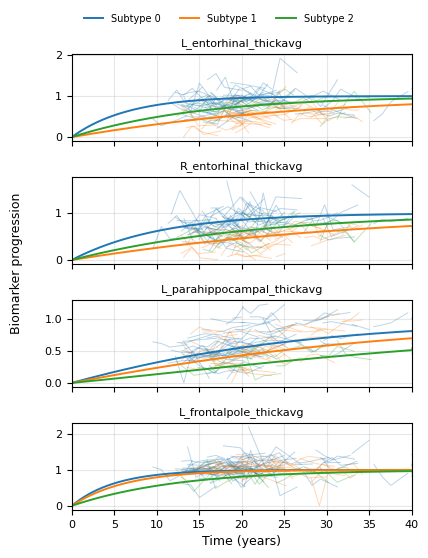

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from EMDPM.utils import solve_system

top_n = 10
top_indices = np.argsort(curve_l2_max)[-top_n:][::-1]
top_ROI_names = [biomarker_names[idx] for idx in top_indices]

final_scalar_K = best_data["final_scalar_K"]
x0 = np.zeros(n_biomarkers)

subtype_colors = plt.cm.tab10(np.arange(n_subtypes) / 10)
patient_alpha = 0.3

pids_with_subtype = [p for p in np.unique(ids_all) if pid_to_assignment.get(p, -1) >= 0]
assignment_per_obs = np.array([pid_to_assignment.get(p, -1) for p in ids_all])

# Only ROIs 0,1,2,5 within the top list
roi_positions = [0, 1, 2, 5]
roi_positions = [i for i in roi_positions if i < len(top_indices)]
selected_indices = [top_indices[i] for i in roi_positions]
selected_names = [top_ROI_names[i] for i in roi_positions]

# Narrower and taller: better aspect for 4 stacked panels
fig, axes = plt.subplots(
    len(selected_indices), 1,
    figsize=(4.3, 6.0),   # width ~single column, taller overall
    sharex=True,
)

if len(selected_indices) == 1:
    axes = [axes]

for ax, roi_idx, roi_name in zip(axes, selected_indices, selected_names):
    # Spaghetti trajectories (patients)
    for pid in pids_with_subtype:
        mask = ids_all == pid
        if mask.sum() < 2:
            continue
        beta_i = pid_to_beta.get(pid, np.nan)
        if np.isnan(beta_i):
            continue
        t_vals = dt_all[mask] + beta_i
        y_vals = X_obs[mask, roi_idx]
        order = np.argsort(t_vals)
        t_vals = t_vals[order]
        y_vals = y_vals[order]
        sub = pid_to_assignment.get(pid, -1)
        if sub < 0:
            continue
        ax.plot(
            t_vals,
            y_vals,
            color=subtype_colors[sub],
            alpha=patient_alpha,
            linewidth=0.7,   # thinner
        )

    # Model trajectories
    for subtype in range(n_subtypes):
        f_subtype = cluster_f[subtype]
        Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K)
        ax.plot(
            t_span,
            Xtraj_subtype[roi_idx],
            color=subtype_colors[subtype],
            linewidth=1.4,   # slightly thinner
        )

    #ax.set_ylabel("Biomarker progression", fontsize=9)
    ax.set_title(roi_name, fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)
    ax.tick_params(axis="both", labelsize=8)

axes[-1].set_xlabel("Time (years)", fontsize=9)

# Single subtype legend above all panels
legend_handles = [
    Line2D([0], [0], color=subtype_colors[k], lw=1.4, label=f"Subtype {k}")
    for k in range(n_subtypes)
]

fig.text(
    0.03, 0.5, "Biomarker progression",
    rotation="vertical",
    va="center",
    ha="center",
    fontsize=9,
)

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=n_subtypes,
    fontsize=7,
    frameon=False,
)

plt.tight_layout(rect=[0.06, 0, 1, 0.9])  # leave space for shared y-label + legend
plt.savefig("spaghetti_top_rois_tall.pdf", bbox_inches="tight", dpi=300)
plt.show()

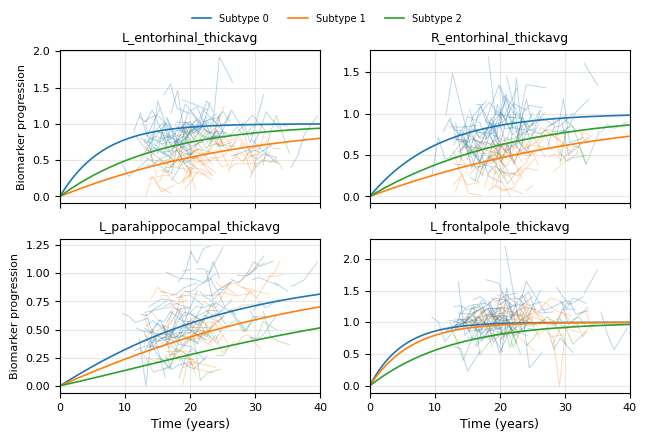

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from EMDPM.utils import solve_system

top_n = 10
top_indices = np.argsort(curve_l2_max)[-top_n:][::-1]
top_ROI_names = [biomarker_names[idx] for idx in top_indices]

final_scalar_K = best_data["final_scalar_K"]
x0 = np.zeros(n_biomarkers)

subtype_colors = plt.cm.tab10(np.arange(n_subtypes) / 10)
patient_alpha = 0.3

pids_with_subtype = [p for p in np.unique(ids_all) if pid_to_assignment.get(p, -1) >= 0]

# Only ROIs 0,1,2,5 within the "top" list
roi_positions = [0, 1, 2, 5]
roi_positions = [i for i in roi_positions if i < len(top_indices)]
selected_indices = [top_indices[i] for i in roi_positions][:4]
selected_names = [top_ROI_names[i] for i in roi_positions][:4]

fig, axes = plt.subplots(
    2, 2,
    figsize=(6.5, 4.5),   # 2x2 layout
    sharex=True,
)

axes = axes.flatten()

for ax_idx, (ax, roi_idx, roi_name) in enumerate(zip(axes, selected_indices, selected_names)):
    # Spaghetti: patient trajectories
    for pid in pids_with_subtype:
        mask = ids_all == pid
        if mask.sum() < 2:
            continue
        beta_i = pid_to_beta.get(pid, np.nan)
        if np.isnan(beta_i):
            continue
        t_vals = dt_all[mask] + beta_i
        y_vals = X_obs[mask, roi_idx]
        order = np.argsort(t_vals)
        t_vals = t_vals[order]
        y_vals = y_vals[order]
        sub = pid_to_assignment.get(pid, -1)
        if sub < 0:
            continue
        ax.plot(
            t_vals,
            y_vals,
            color=subtype_colors[sub],
            alpha=patient_alpha,
            linewidth=0.7,
        )

    # Model trajectories
    for subtype in range(n_subtypes):
        f_subtype = cluster_f[subtype]
        Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K)
        ax.plot(
            t_span,
            Xtraj_subtype[roi_idx],
            color=subtype_colors[subtype],
            linewidth=1.2,
        )

    row, col = divmod(ax_idx, 2)
    if col == 0:
        ax.set_ylabel("Biomarker progression", fontsize=8)
    ax.set_title(roi_name, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)
    ax.tick_params(axis="both", labelsize=8)

# Shared x-label only on bottom row
for ax in axes[-2:]:
    ax.set_xlabel("Time (years)", fontsize=9)

# Single legend for subtypes
legend_handles = [
    Line2D([0], [0], color=subtype_colors[k], lw=1.2, label=f"Subtype {k}")
    for k in range(n_subtypes)
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=n_subtypes,
    fontsize=7,
    frameon=False,
)

plt.tight_layout()
plt.subplots_adjust(top=0.88)  # room for legend
plt.savefig("spaghetti_top_rois_2x2.pdf", bbox_inches="tight", dpi=300)
plt.show()

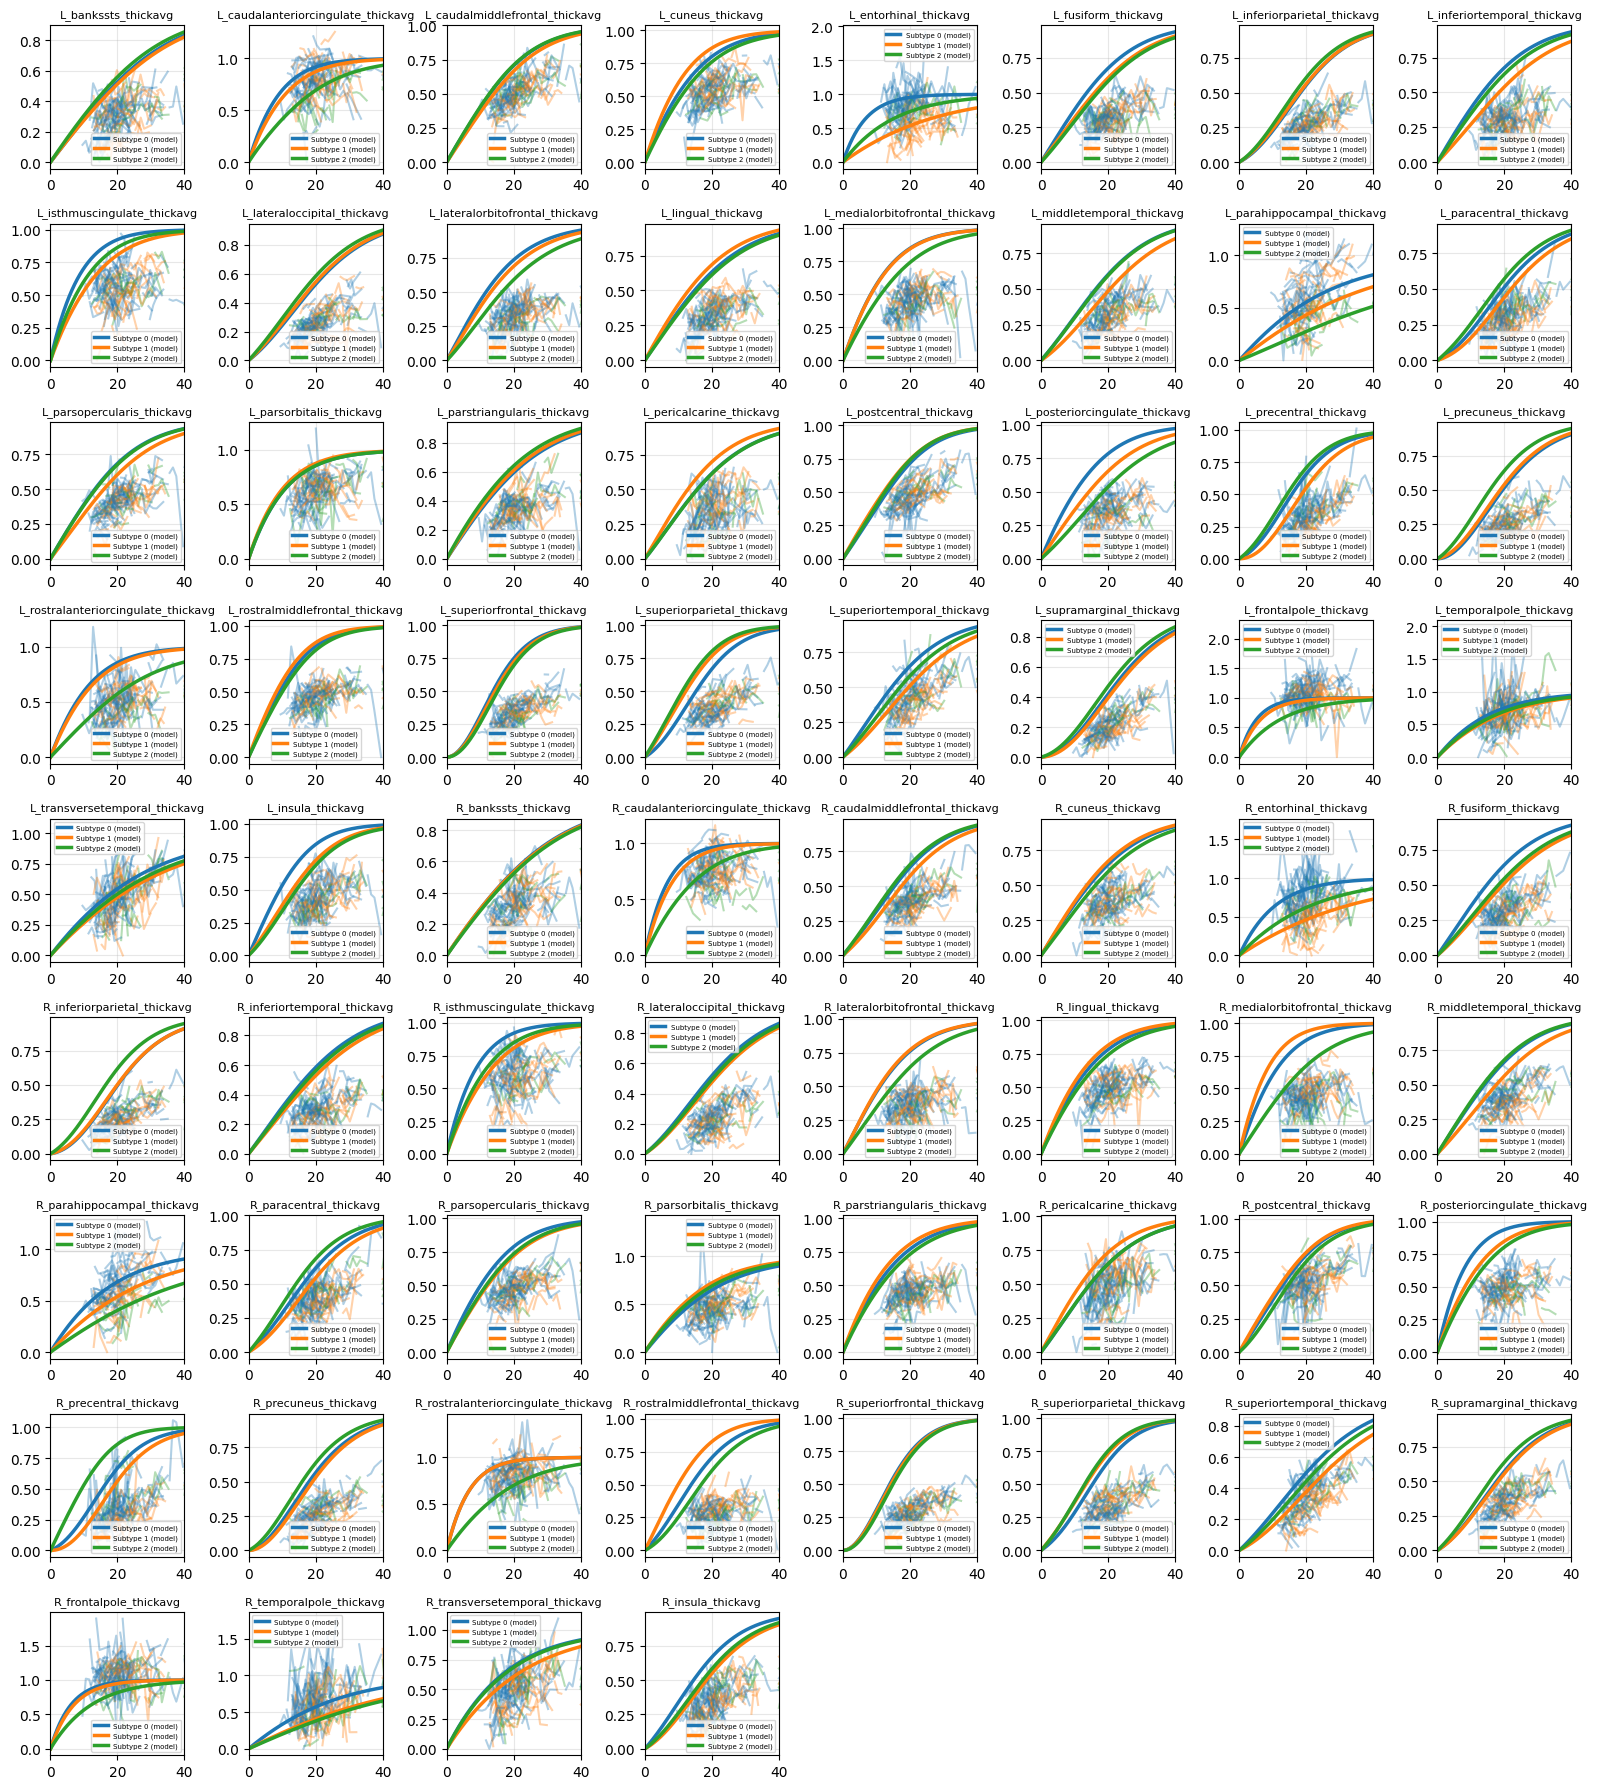

In [ ]:
# Spaghetti plots: all 68 regions in 8×9 grid; patient trajectories (transparent) + model trajectories (solid) by subtype

import numpy as np
import matplotlib.pyplot as plt
from EMDPM.utils import solve_system

cluster_f = best_data["cluster_f"]
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]

# All 68 regions (no top-N filter)
top_indices = np.arange(n_biomarkers)
top_ROI_names = [biomarker_names[idx] for idx in top_indices]

final_scalar_K = best_data["final_scalar_K"]
x0 = np.zeros(n_biomarkers)

subtype_colors = plt.cm.tab10(np.arange(n_subtypes) / 10)
patient_alpha = 0.35

pids_with_subtype = [p for p in np.unique(ids_all) if pid_to_assignment.get(p, -1) >= 0]

# 8 columns × 9 rows; square subplots (e.g. 2 inches per side)
n_cols, n_rows = 8, 9
ax_size = 2.0
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * ax_size, n_rows * ax_size))
axes_flat = axes.ravel()

for i, (roi_idx, roi_name) in enumerate(zip(top_indices, top_ROI_names)):
    ax = axes_flat[i]
    # 1) Spaghetti: one line per patient (colored by subtype, transparent)
    for pid in pids_with_subtype:
        mask = ids_all == pid
        if mask.sum() < 2:
            continue
        beta_i = pid_to_beta.get(pid, np.nan)
        if np.isnan(beta_i):
            continue
        t_vals = dt_all[mask] + beta_i
        y_vals = X_obs[mask, roi_idx]
        order = np.argsort(t_vals)
        t_vals = t_vals[order]
        y_vals = y_vals[order]
        sub = pid_to_assignment.get(pid, -1)
        if sub < 0:
            continue
        ax.plot(t_vals, y_vals, color=subtype_colors[sub], alpha=patient_alpha, linewidth=1.5)

    # 2) Model trajectories (solid) for each subtype
    for subtype in range(n_subtypes):
        f_subtype = cluster_f[subtype]
        Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K)
        ax.plot(t_span, Xtraj_subtype[roi_idx], color=subtype_colors[subtype], linewidth=2.5,
                label=f"Subtype {subtype} (model)")

    ax.set_title(roi_name, fontsize=8)
    ax.legend(loc="best", fontsize=5)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)

# Hide unused subplots (68 regions, 72 slots)
for j in range(n_biomarkers, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Export per-subtype biomarker values (fitted trajectories, no supremum) at t=10, 25, 40 and forcing terms for brain visualization
import numpy as np
from EMDPM.utils import solve_system

# Time points (years) to sample
TIME_POINTS = np.array([10.0, 20.0, 25.0, 30.0, 40.0])

cluster_f = best_data["cluster_f"]  # (n_subtypes, n_biomarkers)
final_scalar_K = best_data["final_scalar_K"]
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]
x0 = np.zeros(n_biomarkers)

# Fitted trajectories without supremum (raw ODE solution), then clip to [0,1]
biomarker_at_times = []  # list of (3, n_biomarkers) for t=10, 25, 40
for k in range(n_subtypes):
    Xtraj = solve_system(x0, cluster_f[k], K, t_span, final_scalar_K)  # (n_biomarkers, len(t_span))
    # Sample at t = 10, 25, 40 (interpolate if needed)
    vals = np.zeros((len(TIME_POINTS), n_biomarkers))
    for ti, t in enumerate(TIME_POINTS):
        idx = np.argmin(np.abs(t_span - t))
        vals[ti] = Xtraj[:, idx]
    # Clip to [0,1] for easy comparison (no supremum)
    vals = np.clip(vals, 0.0, 1.0)
    biomarker_at_times.append(vals)

# (n_subtypes, 3, n_biomarkers) — dim 1 is t=10, 25, 40
biomarker_at_times = np.stack(biomarker_at_times, axis=0)

# Forcing terms: (n_subtypes, n_biomarkers)
forcing_terms = np.asarray(cluster_f)

out_dir = "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/2026_2_22_ppmi_new_bic_iitconnect_2"
np.save(f"{out_dir}/subtype_biomarker_at_t10_t20_t25_t30_t40.npy", biomarker_at_times)
np.save(f"{out_dir}/subtype_forcing_terms.npy", forcing_terms)
print(f"Saved biomarker_at_times shape: {biomarker_at_times.shape} (n_subtypes, 3 times, n_biomarkers)")
print(f"Saved forcing_terms shape: {forcing_terms.shape} (n_subtypes, n_biomarkers)")
print(f"Times: {TIME_POINTS}")

Saved biomarker_at_times shape: (3, 5, 68) (n_subtypes, 3 times, n_biomarkers)
Saved forcing_terms shape: (3, 68) (n_subtypes, n_biomarkers)
Times: [10. 20. 25. 30. 40.]
